# CTA Ridership Time Series Forecasting

**University of Chicago - Master of Science in Applied Data Science**

**ADSP 31006: Time Series Analysis and Forecasting**

---

## Table of Contents
1. [Problem Statement](#1-problem-statement)
2. [Assumptions and Hypotheses](#2-assumptions)
3. [Data Loading and EDA](#3-eda)
4. [Data Processing](#4-data-processing)
5. [Feature Engineering](#5-feature-engineering)
6. [Structural Break Analysis](#6-structural-break)
   - 6.1 Chow Test
   - 6.2 Intervention Analysis (SARIMAX)
   - 6.3 Bayesian Causal Impact
7. [Modeling](#7-modeling)
   - 7.2 SARIMA | 7.3 GARCH | 7.4 Prophet | 7.5 LSTM
8. [Results and Evaluation](#8-results)
9. [Future Work](#9-future-work)


## Setup and Imports

In [6]:
# Setup virtual environment and install dependencies (run once)
# After it finishes, go to Kernel → Change Kernel → "CTA Forecasting", then run from the next cell.

import subprocess, sys, os

VENV_DIR = os.path.expanduser('~/cta_env')

if not os.path.exists(VENV_DIR):
    print('1/3  Creating virtual environment...')
    subprocess.check_call([sys.executable, '-m', 'venv', VENV_DIR])

    pip = os.path.join(VENV_DIR, 'bin', 'pip')
    python = os.path.join(VENV_DIR, 'bin', 'python')

    print('2/3  Installing packages (this may take a few minutes)...')
    subprocess.check_call([pip, 'install', '--quiet',
        'numpy<2',
        'pandas<3',
        'matplotlib',
        'seaborn',
        'scipy',
        'statsmodels',
        'arch',
        'prophet',
        'scikit-learn',
        'tensorflow',
        'jinja2',
        'pycausalimpact',
        'plotly',
        'ipykernel',
    ])

    print('3/3  Registering Jupyter kernel...')
    subprocess.check_call([
        python, '-m', 'ipykernel', 'install',
        '--user', '--name', 'cta_env', '--display-name', 'CTA Forecasting'
    ])

    print('\n\u2713 Done! Now go to Kernel \u2192 Change Kernel \u2192 CTA Forecasting')
    print('  Then run all cells starting from the NEXT cell (imports).')
else:
    # If venv exists but missing packages, install them
    pip = os.path.join(VENV_DIR, 'bin', 'pip')
    subprocess.check_call([pip, 'install', '--quiet', 'pycausalimpact', 'plotly'])
    print(f'Virtual environment already exists at {VENV_DIR}')
    print('Ensured pycausalimpact and plotly are installed.')
    print('Switch to it via Kernel \u2192 Change Kernel \u2192 CTA Forecasting')


Virtual environment already exists at /Users/leyixu/cta_env
Ensured pycausalimpact and plotly are installed.
Switch to it via Kernel → Change Kernel → CTA Forecasting



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [7]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Statistical tests
from scipy import stats
from scipy.stats import jarque_bera, shapiro
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

# Models
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model  # For GARCH
from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Causal Impact (Bayesian structural time series)
try:
    from causalimpact import CausalImpact
    print('causalimpact imported successfully')
except ImportError:
    try:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pycausalimpact'])
        from causalimpact import CausalImpact
        print('pycausalimpact installed and imported successfully')
    except Exception as e:
        print(f'Warning: Could not import CausalImpact: {e}')
        print('Install manually: pip install pycausalimpact')
        CausalImpact = None

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_palette('husl')

# Random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print('All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')


causalimpact imported successfully
All libraries imported successfully!
TensorFlow version: 2.20.0


---
## 1. Problem Statement <a id='1-problem-statement'></a>

### Business Context
The Chicago Transit Authority (CTA) operates the second-largest public transit system in the US, serving ~1.6 million weekday rides across its rail (L train) and bus networks.

Accurate ridership forecasting supports operational scheduling, resource allocation, revenue projections, and long-term capacity planning.

### Forecasting Objective
Develop 90-day ridership forecasts at the system-wide daily level using real CTA boarding data from January 2001 through November 2025 (9,100 daily observations). We also quantify the COVID-19 structural break through intervention analysis and Bayesian causal inference.

### Research Questions
1. How do temporal patterns (daily, weekly, seasonal) influence CTA ridership?
2. Is there volatility clustering (ARCH effects) in ridership variations?
3. Which forecasting models best capture urban transit demand dynamics?
4. What is the causal impact of COVID-19 on ridership, and has it recovered?
5. Can an intervention model (SARIMAX with structural break dummies) improve forecasts?
6. Does LSTM outperform classical statistical models on real transit data?


---
## 2. Assumptions and Hypotheses <a id='2-assumptions'></a>

### 2.1 Data Assumptions
- A1: CTA ridership data accurately reflects actual boardings with minimal measurement error
- A2: Missing values are random (MCAR)
- A3: Historical pre-COVID patterns provide informative priors for forecasting
- A4: The COVID-19 intervention date (March 15, 2020) is a known, exogenous structural break

### 2.2 Modeling Hypotheses
- H1: Ridership exhibits strong weekly (weekday vs. weekend) and annual seasonality
- H2: The series is non-stationary in levels but stationary after differencing
- H3: ARCH effects (volatility clustering) exist in ridership variations
- H4: ARIMA residuals exhibit heteroscedasticity requiring GARCH modeling
- H5: LSTM captures complex nonlinear patterns better than classical methods
- H6: COVID-19 represents a structural break testable through intervention analysis
- H7: Post-COVID ridership equilibrium is permanently lower than pre-COVID (regime change)
- H8: A Bayesian causal impact framework can estimate the counterfactual ridership without COVID


## 3. Data Loading and EDA <a id="3-eda"></a>

Data is loaded directly from the [Chicago Data Portal](https://data.cityofchicago.org/Transportation/CTA-Ridership-Daily-Boarding-Totals/6iiy-9s97) via the Socrata Open Data API (SODA). The dataset contains systemwide daily boarding totals for CTA bus and rail services dating back to 2001.

**Columns:**
- `service_date`: Date of service
- `day_type`: W = Weekday, A = Saturday, U = Sunday/Holiday
- `bus`: Total bus boardings
- `rail_boardings`: Total rail boardings
- `total_rides`: Combined bus + rail boardings

In [3]:
# Load CTA ridership data from Chicago Data Portal
# Dataset: CTA - Ridership - Daily Boarding Totals
# Source: https://data.cityofchicago.org/Transportation/CTA-Ridership-Daily-Boarding-Totals/6iiy-9s97

url = "https://data.cityofchicago.org/resource/6iiy-9s97.csv?$limit=50000&$order=service_date"

try:
    df_raw = pd.read_csv(url, parse_dates=['service_date'])
    print(f"Successfully loaded data from Chicago Data Portal API")
except Exception as e:
    print(f"API fetch failed ({e}), trying direct download URL...")
    url_backup = "https://data.cityofchicago.org/api/views/6iiy-9s97/rows.csv?accessType=DOWNLOAD"
    df_raw = pd.read_csv(url_backup, parse_dates=['service_date'])
    print(f"Successfully loaded data from direct download")

# Ensure numeric columns are properly typed
for col in ['bus', 'rail_boardings', 'total_rides']:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# Drop any rows with missing ridership values
df_raw = df_raw.dropna(subset=['total_rides'])

print(f"Dataset shape: {df_raw.shape}")
print(f"Date range: {df_raw['service_date'].min().date()} to {df_raw['service_date'].max().date()}")
print(f"Columns: {df_raw.columns.tolist()}")
print(f"\nSample data:")
df_raw.head()

Successfully loaded data from Chicago Data Portal API
Dataset shape: (9100, 5)
Date range: 2001-01-01 to 2025-11-30
Columns: ['service_date', 'day_type', 'bus', 'rail_boardings', 'total_rides']

Sample data:


,service_date,day_type,bus,rail_boardings,total_rides
0,2001-01-01,U,297192,126455,423647
1,2001-01-02,W,780827,501952,1282779
2,2001-01-03,W,824923,536432,1361355
3,2001-01-04,W,870021,550011,1420032
4,2001-01-05,W,890426,557917,1448343


In [4]:
# Data preprocessing
df = df_raw.copy()
df['service_date'] = pd.to_datetime(df['service_date'])
df = df.sort_values('service_date').reset_index(drop=True)
df.set_index('service_date', inplace=True)

# Ensure no duplicate dates (take the first occurrence if any)
df = df[~df.index.duplicated(keep='first')]

# Add temporal features
df['year'] = df.index.year
df['month'] = df.index.month
df['day_of_week'] = df.index.dayofweek
df['day_name'] = df.index.day_name()
df['is_weekend'] = df['day_of_week'] >= 5

print("Dataset Info:")
print(f"Total records: {len(df):,}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"\nDay type distribution:")
print(df['day_type'].value_counts())
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDescriptive Statistics:")
df[['bus', 'rail_boardings', 'total_rides']].describe()

Dataset Info:
Total records: 9,100
Date range: 2001-01-01 to 2025-11-30

Day type distribution:
day_type
W    6355
U    1449
A    1296
Name: count, dtype: int64

Missing values:
day_type          0
bus               0
rail_boardings    0
total_rides       0
year              0
month             0
day_of_week       0
day_name          0
is_weekend        0
dtype: int64

Descriptive Statistics:


,bus,rail_boardings,total_rides
count,9.100000e+03,9.100000e+03,9.100000e+03
mean,7.044593e+05,5.064497e+05,1.210909e+06
std,2.691563e+05,2.067194e+05,4.629037e+05
min,8.078300e+04,2.354400e+04,1.100470e+05
25%,4.607805e+05,3.265512e+05,7.975130e+05
50%,7.505730e+05,5.718135e+05,1.399761e+06
75%,9.553080e+05,6.876832e+05,1.626020e+06
max,1.211992e+06,1.146516e+06,2.049519e+06


### 3.2 Time Series Visualization

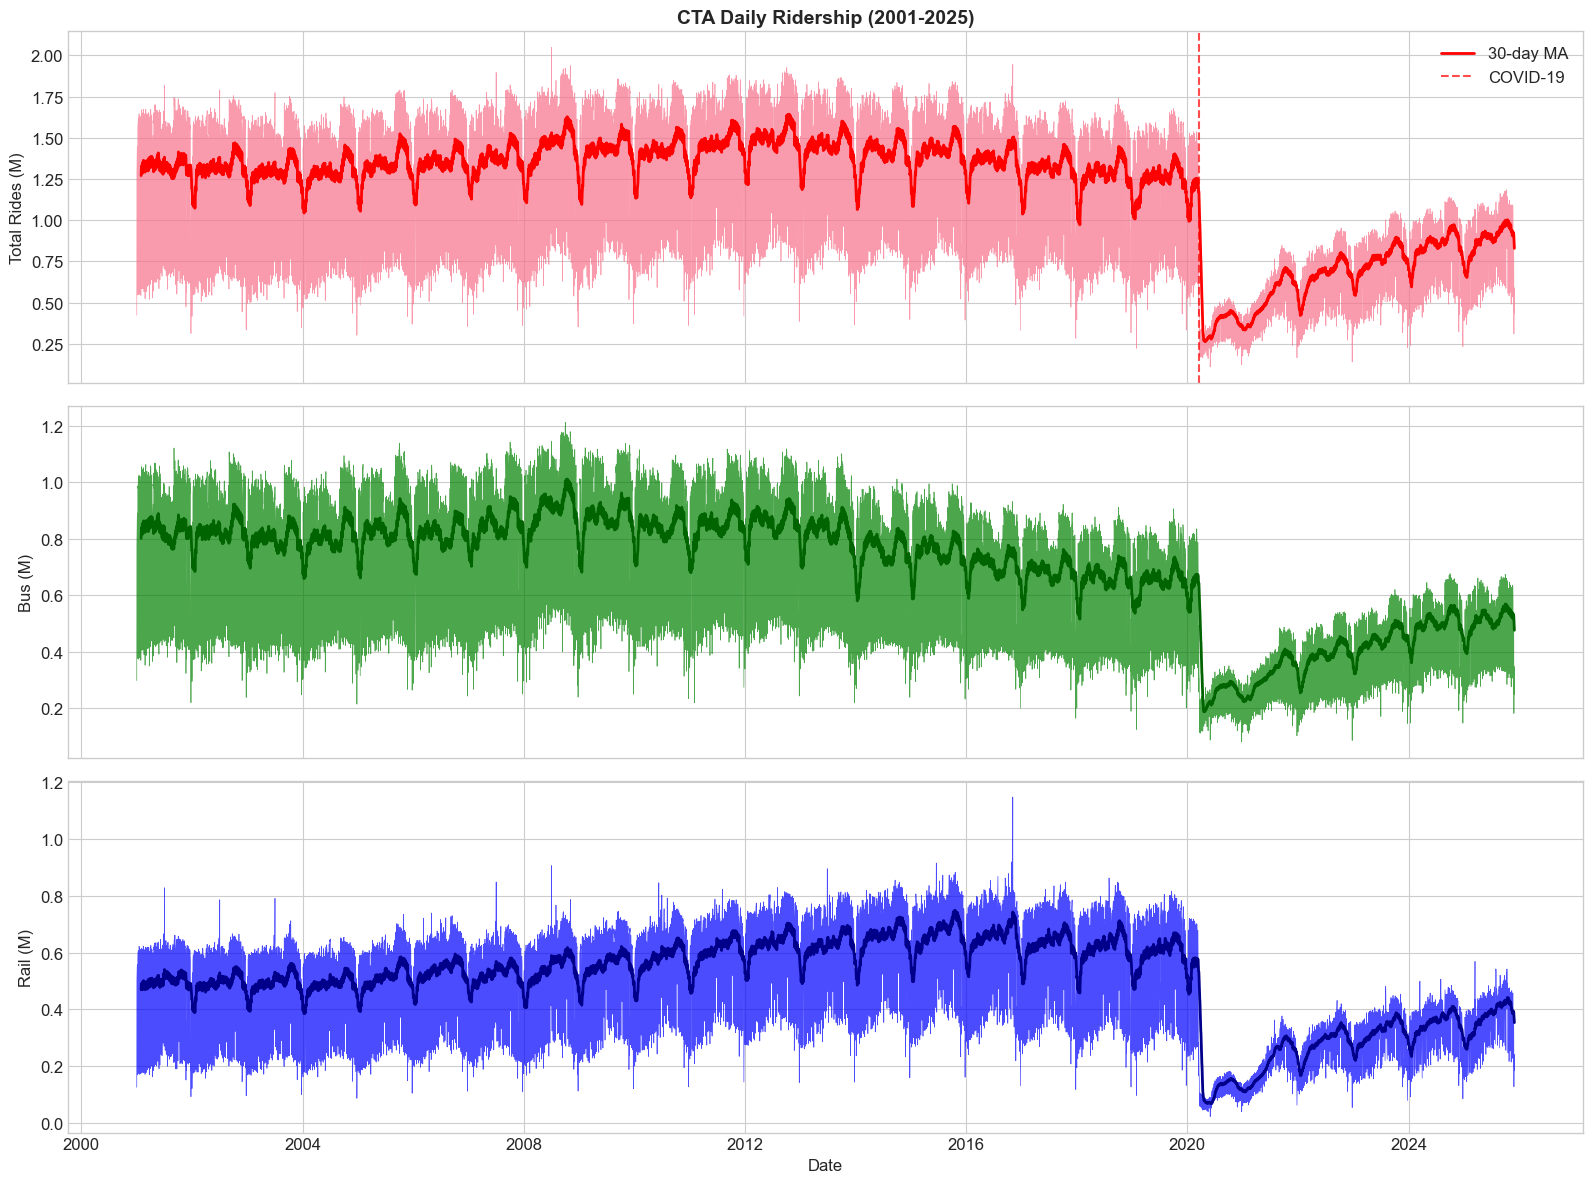

In [5]:
# Full time series plot
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

year_min = df.index.min().year
year_max = df.index.max().year

axes[0].plot(df.index, df['total_rides']/1e6, linewidth=0.5, alpha=0.7)
axes[0].plot(df.index, df['total_rides'].rolling(30).mean()/1e6, color='red', linewidth=2, label='30-day MA')
axes[0].set_ylabel('Total Rides (M)')
axes[0].set_title(f'CTA Daily Ridership ({year_min}-{year_max})', fontsize=14, fontweight='bold')
axes[0].axvline(pd.Timestamp('2020-03-15'), color='red', linestyle='--', alpha=0.7, label='COVID-19')
axes[0].legend()

axes[1].plot(df.index, df['bus']/1e6, linewidth=0.5, alpha=0.7, color='green')
axes[1].plot(df.index, df['bus'].rolling(30).mean()/1e6, color='darkgreen', linewidth=2)
axes[1].set_ylabel('Bus (M)')

axes[2].plot(df.index, df['rail_boardings']/1e6, linewidth=0.5, alpha=0.7, color='blue')
axes[2].plot(df.index, df['rail_boardings'].rolling(30).mean()/1e6, color='darkblue', linewidth=2)
axes[2].set_ylabel('Rail (M)')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.savefig('01_time_series_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Seasonality Analysis

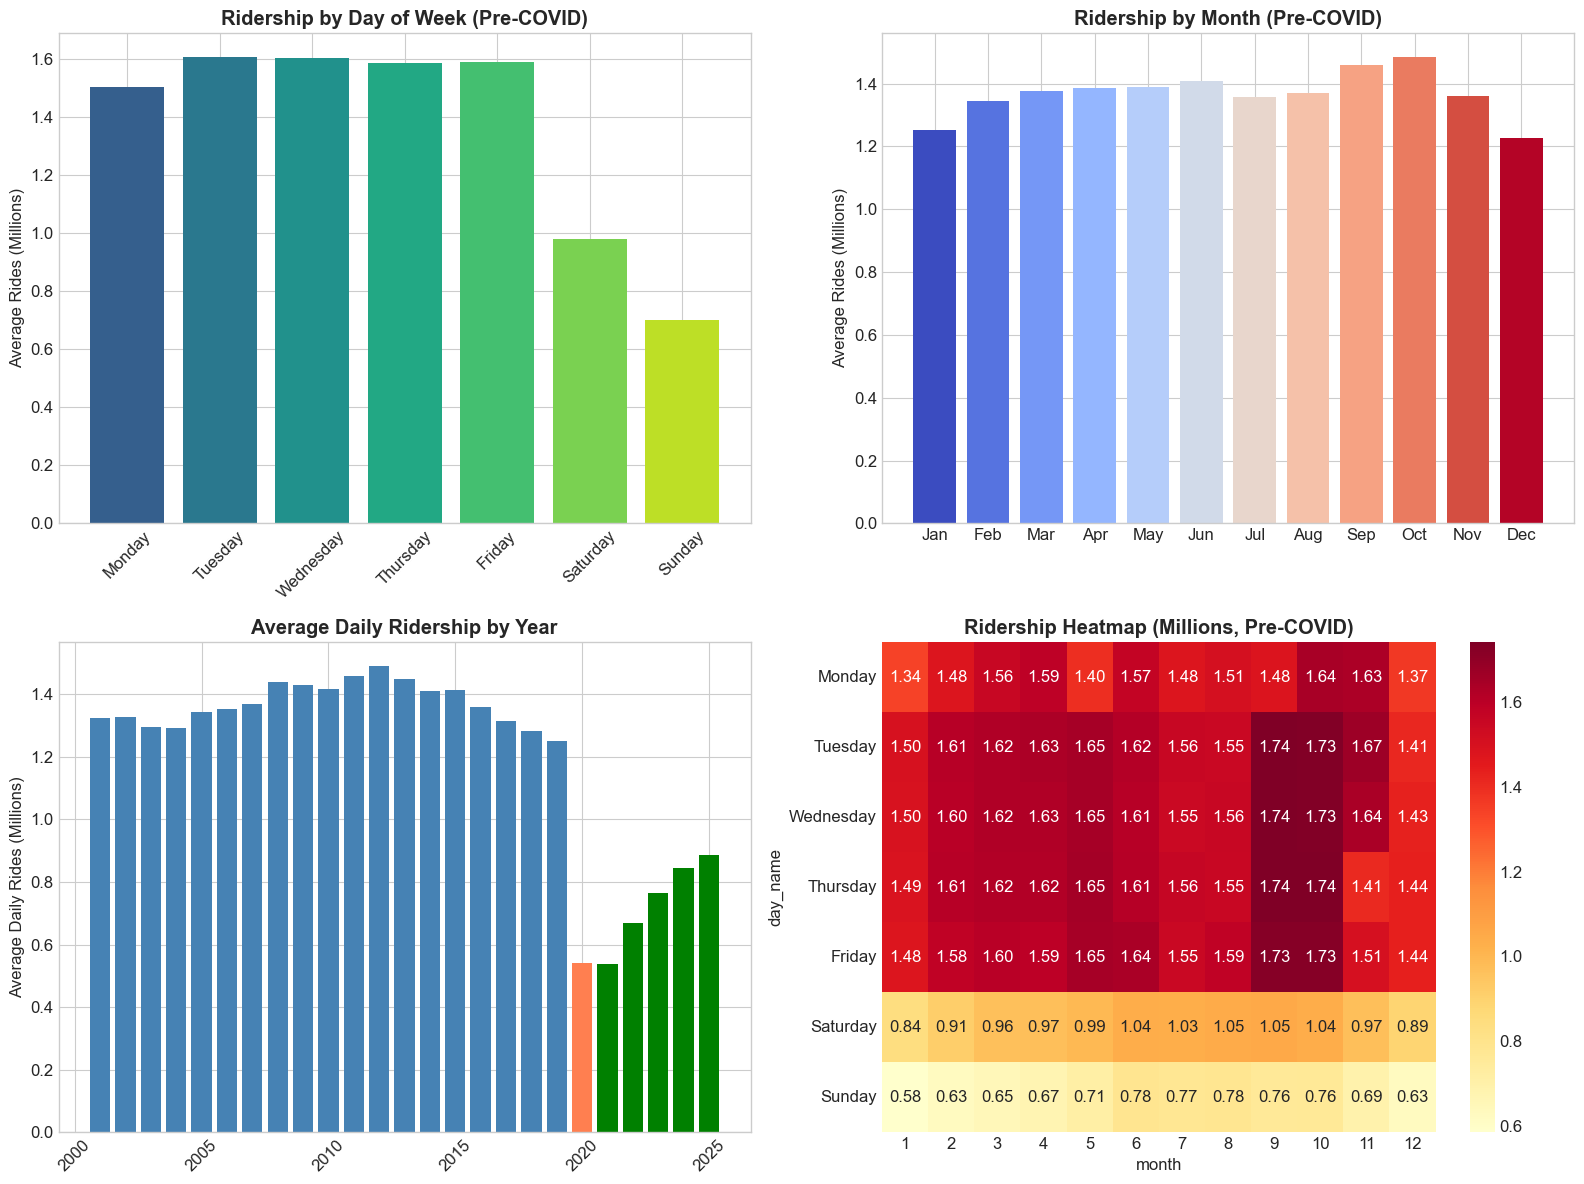

In [6]:
# Focus on pre-COVID for pattern analysis
df_pre_covid = df[df.index < '2020-03-01']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Day of week pattern
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_pattern = df_pre_covid.groupby('day_name')['total_rides'].mean().reindex(day_order) / 1e6
axes[0, 0].bar(day_order, day_pattern, color=plt.cm.viridis(np.linspace(0.3, 0.9, 7)))
axes[0, 0].set_ylabel('Average Rides (Millions)')
axes[0, 0].set_title('Ridership by Day of Week (Pre-COVID)', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

# Monthly pattern
month_pattern = df_pre_covid.groupby('month')['total_rides'].mean() / 1e6
axes[0, 1].bar(range(1, 13), month_pattern, color=plt.cm.coolwarm(np.linspace(0, 1, 12)))
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
axes[0, 1].set_ylabel('Average Rides (Millions)')
axes[0, 1].set_title('Ridership by Month (Pre-COVID)', fontweight='bold')

# Yearly trend
yearly = df.groupby('year')['total_rides'].mean() / 1e6
colors = ['steelblue' if y < 2020 else 'coral' if y == 2020 else 'green' for y in yearly.index]
axes[1, 0].bar(yearly.index, yearly.values, color=colors)
axes[1, 0].set_ylabel('Average Daily Rides (Millions)')
axes[1, 0].set_title('Average Daily Ridership by Year', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

# Heatmap
pivot = df_pre_covid.pivot_table(values='total_rides', index='day_name', columns='month', aggfunc='mean') / 1e6
pivot = pivot.reindex(day_order)
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.2f', ax=axes[1, 1])
axes[1, 1].set_title('Ridership Heatmap (Millions, Pre-COVID)', fontweight='bold')

plt.tight_layout()
plt.savefig('02_seasonality_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Stationarity Tests

In [7]:
def stationarity_tests(series, name):
    """Run ADF and KPSS tests with proper interpretation"""
    print(f"\n{'='*60}")
    print(f"Stationarity Tests: {name}")
    print('='*60)

    # ADF Test (H0: unit root exists / series is non-stationary)
    adf = adfuller(series.dropna(), autolag='AIC')
    print(f"\nADF Test (H0: Non-Stationary):")
    print(f"  Statistic: {adf[0]:.4f}, p-value: {adf[1]:.4f}")
    adf_stationary = adf[1] < 0.05
    print(f"  Result: {'Reject H0 → Stationary' if adf_stationary else 'Fail to Reject → Non-Stationary'}")

    # KPSS Test (H0: series is stationary)
    kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"\nKPSS Test (H0: Stationary):")
    print(f"  Statistic: {kpss_result[0]:.4f}, p-value: {kpss_result[1]:.4f}")
    kpss_stationary = kpss_result[1] >= 0.05
    print(f"  Result: {'Fail to Reject → Stationary' if kpss_stationary else 'Reject H0 → Non-Stationary'}")

    # Combined interpretation
    print(f"\n→ Combined Interpretation:")
    if adf_stationary and kpss_stationary:
        print("  BOTH AGREE: Series is STATIONARY")
    elif not adf_stationary and not kpss_stationary:
        print("  BOTH AGREE: Series is NON-STATIONARY (has unit root)")
    elif adf_stationary and not kpss_stationary:
        print("  CONFLICTING: ADF=Stationary, KPSS=Non-Stationary")
        print("  → Series is likely TREND-STATIONARY (stationary around a deterministic trend)")
    else:
        print("  CONFLICTING: ADF=Non-Stationary, KPSS=Stationary")
        print("  → Unusual result, may need further investigation")

    return adf[1], kpss_result[1]

# Test on original series
series = df_pre_covid['total_rides']
stationarity_tests(series, "Original Series")

# Test on differenced series
stationarity_tests(series.diff().dropna(), "First Difference")

# Test on weekly differenced
stationarity_tests(series.diff(7).dropna(), "Weekly Difference (lag-7)")


Stationarity Tests: Original Series

ADF Test (H0: Non-Stationary):
  Statistic: -6.6689, p-value: 0.0000
  Result: Reject H0 → Stationary

KPSS Test (H0: Stationary):
  Statistic: 1.2466, p-value: 0.0100
  Result: Reject H0 → Non-Stationary

→ Combined Interpretation:
  CONFLICTING: ADF=Stationary, KPSS=Non-Stationary
  → Series is likely TREND-STATIONARY (stationary around a deterministic trend)

Stationarity Tests: First Difference

ADF Test (H0: Non-Stationary):
  Statistic: -23.1048, p-value: 0.0000
  Result: Reject H0 → Stationary

KPSS Test (H0: Stationary):
  Statistic: 0.0345, p-value: 0.1000
  Result: Fail to Reject → Stationary

→ Combined Interpretation:
  BOTH AGREE: Series is STATIONARY

Stationarity Tests: Weekly Difference (lag-7)


/var/folders/ns/hcbvd_hd3gxfr2y183d8csgr0000gn/T/ipykernel_34194/2795826298.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
/var/folders/ns/hcbvd_hd3gxfr2y183d8csgr0000gn/T/ipykernel_34194/2795826298.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')



ADF Test (H0: Non-Stationary):
  Statistic: -18.6058, p-value: 0.0000
  Result: Reject H0 → Stationary

KPSS Test (H0: Stationary):
  Statistic: 0.0173, p-value: 0.1000
  Result: Fail to Reject → Stationary

→ Combined Interpretation:
  BOTH AGREE: Series is STATIONARY


/var/folders/ns/hcbvd_hd3gxfr2y183d8csgr0000gn/T/ipykernel_34194/2795826298.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')


(2.0672474246726067e-30, 0.1)

#### Stationarity Findings

The ADF and KPSS tests give conflicting results on the original series, which points to trend-stationarity:

- **Original series**: ADF rejects the unit root (p ≈ 0, statistic = −6.67) but KPSS also rejects stationarity (statistic = 1.25, p = 0.01). This conflict is characteristic of a trend-stationary process — the series is stationary around a deterministic trend (the long-term ridership decline, especially post-COVID).
- **First difference**: Both tests agree on stationarity (ADF = −23.10, KPSS = 0.03), confirming d=1 is sufficient.
- **Weekly difference (lag-7)**: Also clearly stationary (ADF = −18.61, KPSS = 0.02), supporting D=1 with period s=7 for SARIMA.

This supports the SARIMA(1,1,1)(1,1,1,7) specification with both regular and seasonal differencing.


### 3.5 ACF and PACF Analysis

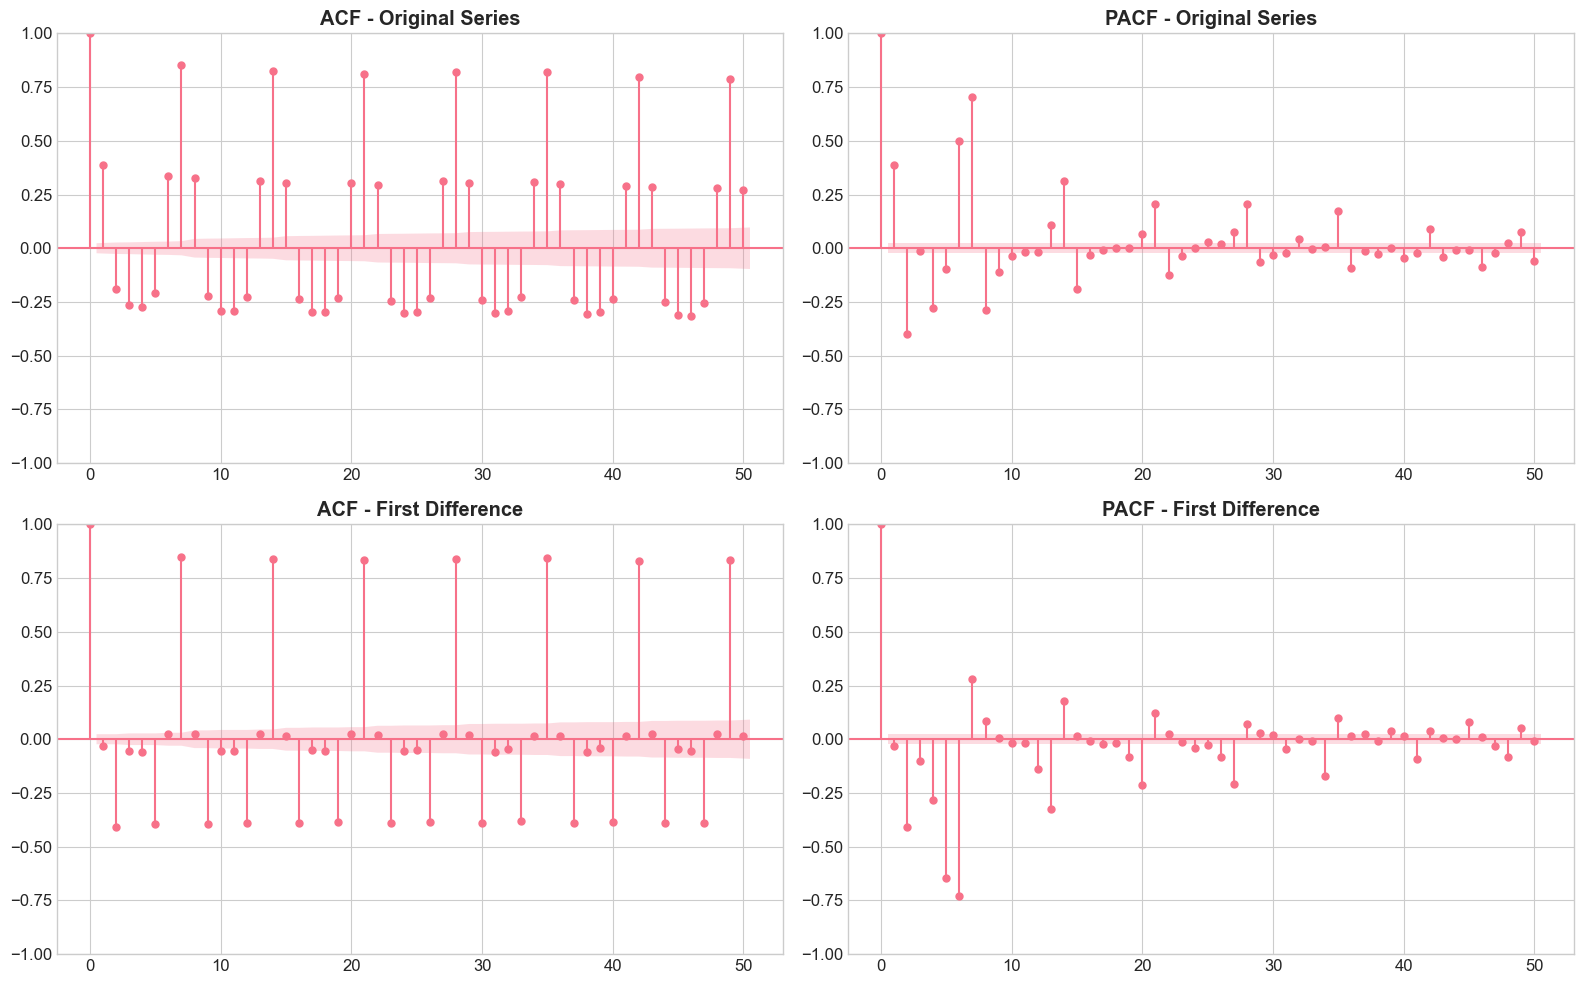


Key Observations:
- Strong autocorrelation at lags 7, 14, 21 (weekly pattern)
- Suggests SARIMA with seasonal period = 7


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_acf(df_pre_covid['total_rides'].dropna(), lags=50, ax=axes[0, 0])
axes[0, 0].set_title('ACF - Original Series', fontweight='bold')

plot_pacf(df_pre_covid['total_rides'].dropna(), lags=50, ax=axes[0, 1])
axes[0, 1].set_title('PACF - Original Series', fontweight='bold')

diff_series = df_pre_covid['total_rides'].diff().dropna()
plot_acf(diff_series, lags=50, ax=axes[1, 0])
axes[1, 0].set_title('ACF - First Difference', fontweight='bold')

plot_pacf(diff_series, lags=50, ax=axes[1, 1])
axes[1, 1].set_title('PACF - First Difference', fontweight='bold')

plt.tight_layout()
plt.savefig('03_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Observations:")
print("- Strong autocorrelation at lags 7, 14, 21 (weekly pattern)")
print("- Suggests SARIMA with seasonal period = 7")

### 3.6 Squared Series Analysis (ARCH Effects Testing)

We test for ARCH effects (volatility clustering) by analyzing squared residuals. This determines whether variance is time-varying and whether GARCH modeling is warranted.


In [9]:
# Compute returns/changes for volatility analysis
returns = df_pre_covid['total_rides'].pct_change().dropna() * 100  # Percentage changes
squared_returns = returns ** 2

print("="*70)
print("SQUARED SERIES ANALYSIS - Testing for ARCH Effects")
print("="*70)

# 1. Jarque-Bera Test for Normality
jb_stat, jb_pvalue = jarque_bera(returns)
print(f"\n1. JARQUE-BERA TEST (Normality of Returns):")
print(f"   Statistic: {jb_stat:.4f}")
print(f"   p-value: {jb_pvalue:.6f}")
print(f"   Result: {'Non-Normal (reject H0)' if jb_pvalue < 0.05 else 'Normal (fail to reject H0)'}")
print(f"   Interpretation: {'Evidence of fat tails/skewness - GARCH may be appropriate' if jb_pvalue < 0.05 else 'Approximately normal'}")

# 2. McLeod-Li Test (Ljung-Box on squared residuals)
print(f"\n2. McLEOD-LI TEST (Ljung-Box on Squared Series):")
lb_squared = acorr_ljungbox(squared_returns, lags=[10, 20, 30], return_df=True)
print(lb_squared)
print(f"   Result: {'ARCH effects present' if (lb_squared['lb_pvalue'] < 0.05).any() else 'No ARCH effects'}")

# 3. Engle's ARCH Test
print(f"\n3. ENGLE'S ARCH-LM TEST:")
arch_test = het_arch(returns, nlags=10)
print(f"   LM Statistic: {arch_test[0]:.4f}")
print(f"   LM p-value: {arch_test[1]:.6f}")
print(f"   F Statistic: {arch_test[2]:.4f}")
print(f"   F p-value: {arch_test[3]:.6f}")
print(f"   Result: {'ARCH effects present - consider GARCH model' if arch_test[1] < 0.05 else 'No significant ARCH effects'}")

SQUARED SERIES ANALYSIS - Testing for ARCH Effects

1. JARQUE-BERA TEST (Normality of Returns):
   Statistic: 5022.3039
   p-value: 0.000000
   Result: Non-Normal (reject H0)
   Interpretation: Evidence of fat tails/skewness - GARCH may be appropriate

2. McLEOD-LI TEST (Ljung-Box on Squared Series):
         lb_stat  lb_pvalue
10   4295.678014        0.0
20   8267.514896        0.0
30  15395.167021        0.0
   Result: ARCH effects present

3. ENGLE'S ARCH-LM TEST:
   LM Statistic: 3776.0500
   LM p-value: 0.000000
   F Statistic: 820.2338
   F p-value: 0.000000
   Result: ARCH effects present - consider GARCH model


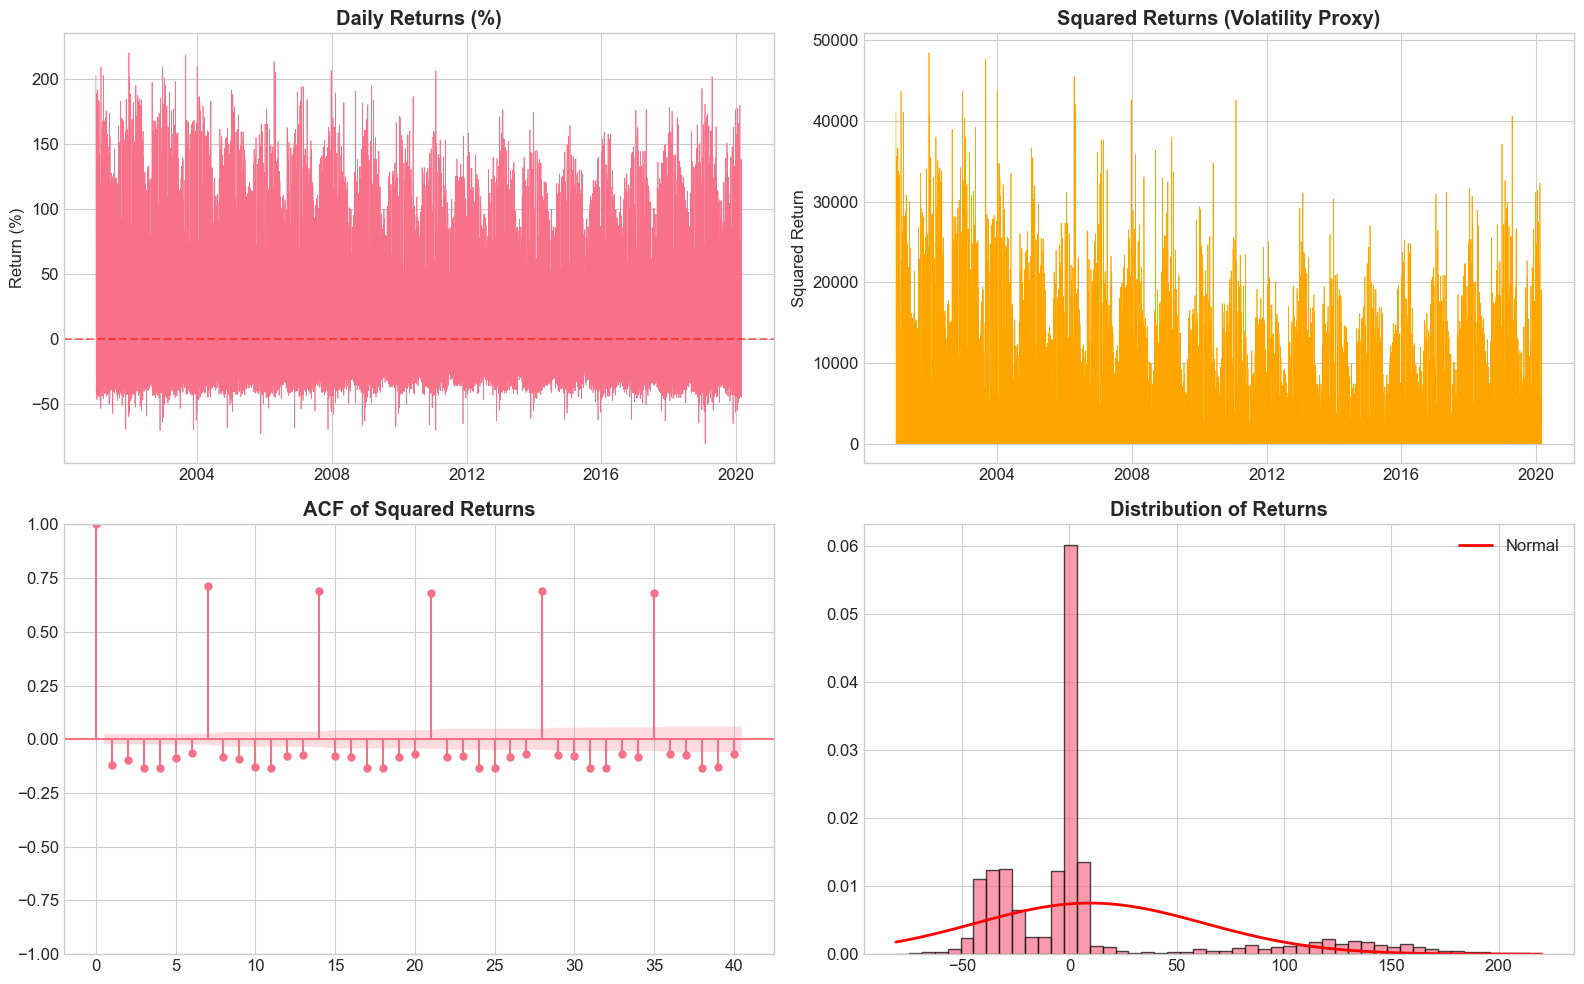


Interpretation:
- Significant ACF in squared returns indicates volatility clustering
- This suggests ARCH/GARCH effects are present
- Large changes tend to be followed by large changes (of either sign)


In [10]:
# Visualize squared series
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Returns
axes[0, 0].plot(returns.index, returns, linewidth=0.5)
axes[0, 0].set_title('Daily Returns (%)', fontweight='bold')
axes[0, 0].set_ylabel('Return (%)')
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)

# Squared returns (shows volatility clustering)
axes[0, 1].plot(squared_returns.index, squared_returns, linewidth=0.5, color='orange')
axes[0, 1].set_title('Squared Returns (Volatility Proxy)', fontweight='bold')
axes[0, 1].set_ylabel('Squared Return')

# ACF of squared returns
plot_acf(squared_returns.dropna(), lags=40, ax=axes[1, 0])
axes[1, 0].set_title('ACF of Squared Returns', fontweight='bold')

# Distribution of returns
axes[1, 1].hist(returns, bins=50, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(returns.min(), returns.max(), 100)
axes[1, 1].plot(x, stats.norm.pdf(x, returns.mean(), returns.std()), 'r-', linewidth=2, label='Normal')
axes[1, 1].set_title('Distribution of Returns', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('- Significant ACF in squared returns indicates volatility clustering')
print('- This suggests ARCH/GARCH effects are present')
print('- Large changes tend to be followed by large changes (of either sign)')


#### ARCH Effects Summary

All three tests confirm ARCH effects in CTA ridership returns:

| Test | Statistic | p-value | Conclusion |
|------|-----------|---------|------------|
| Jarque-Bera | 5,022.30 | ≈ 0 | Non-normal returns (fat tails, skewness = −1.46, kurtosis = 10.80) |
| McLeod-Li (lag 10) | 4,295.68 | 0.0 | Autocorrelation in squared returns |
| Engle's ARCH-LM | 3,776.05 | ≈ 0 | Volatility clustering confirmed |

The high Jarque-Bera statistic reflects the non-normality of daily ridership changes — large swings from holidays, weather, and service disruptions cluster in time. This justifies including a GARCH component in the modeling framework.


### 3.7 STL Decomposition

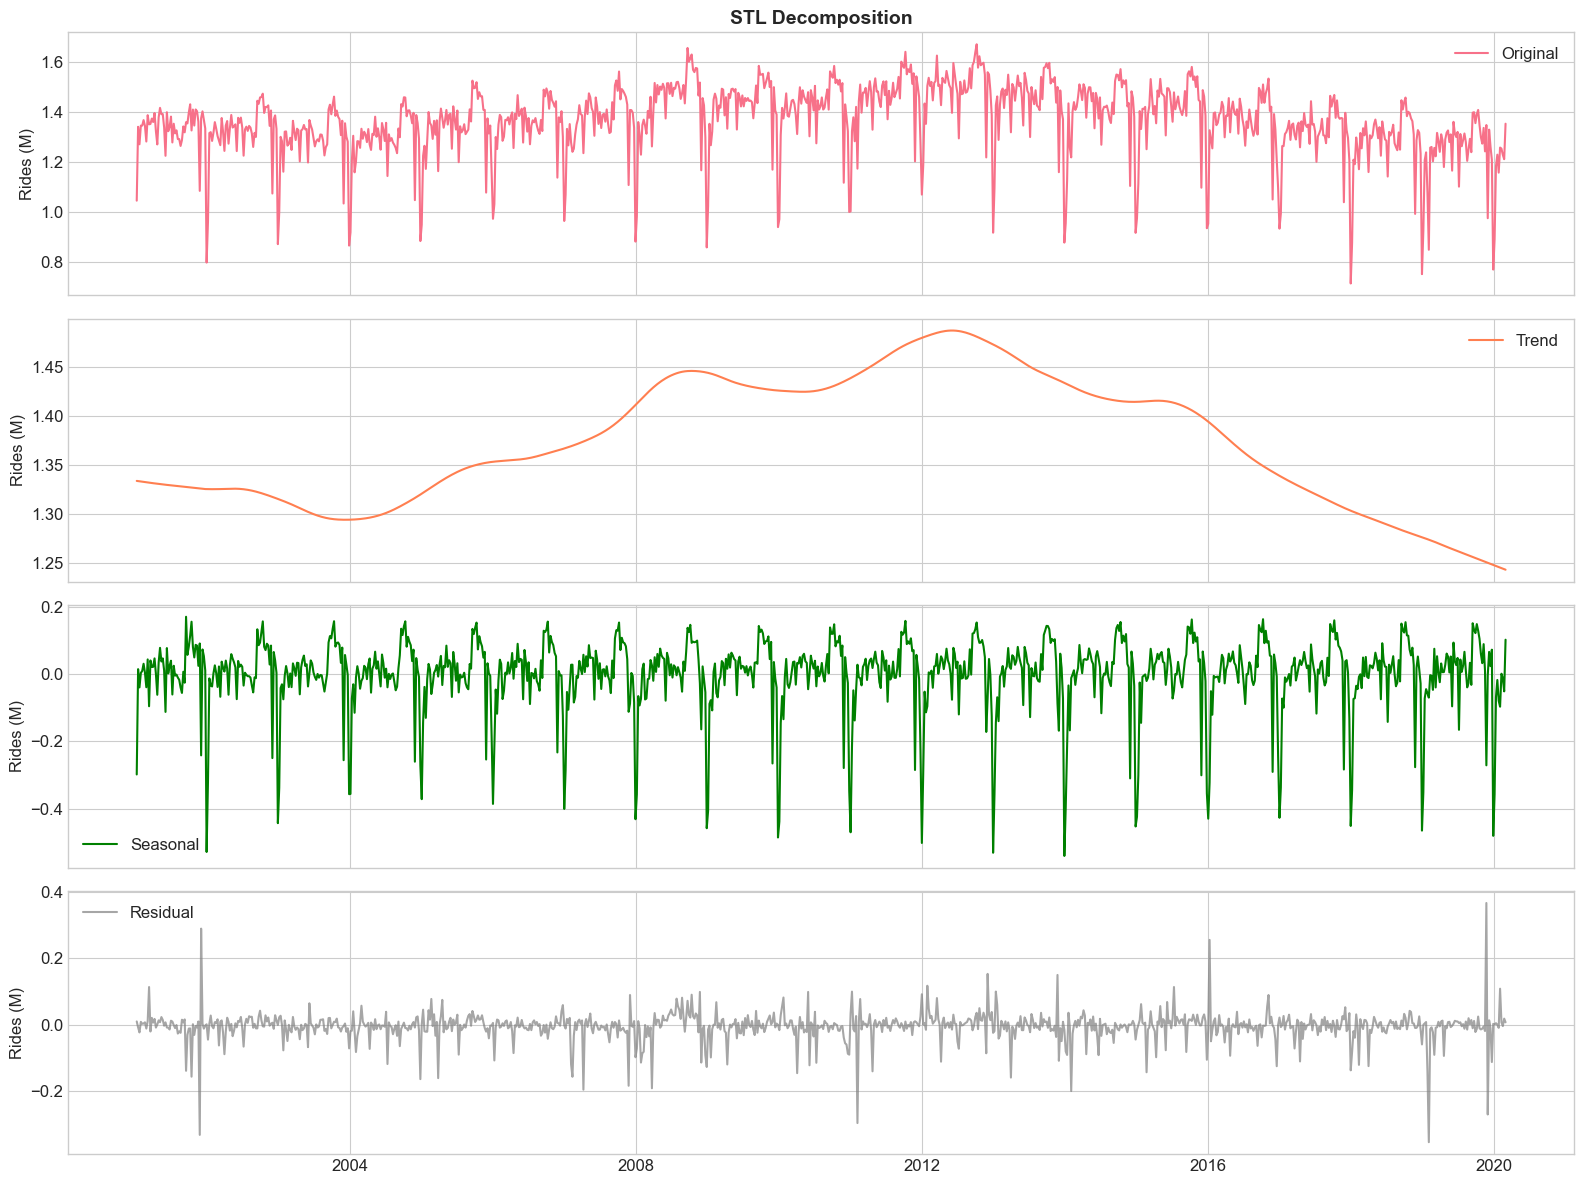

In [11]:
# Weekly aggregation for cleaner decomposition
weekly = df_pre_covid['total_rides'].resample('W').mean()

stl = STL(weekly, period=52, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

axes[0].plot(weekly.index, weekly/1e6)
axes[0].set_ylabel('Rides (M)')
axes[0].set_title('STL Decomposition', fontsize=14, fontweight='bold')
axes[0].legend(['Original'])

axes[1].plot(result.trend.index, result.trend/1e6, color='coral')
axes[1].set_ylabel('Rides (M)')
axes[1].legend(['Trend'])

axes[2].plot(result.seasonal.index, result.seasonal/1e6, color='green')
axes[2].set_ylabel('Rides (M)')
axes[2].legend(['Seasonal'])

axes[3].plot(result.resid.index, result.resid/1e6, color='gray', alpha=0.7)
axes[3].set_ylabel('Rides (M)')
axes[3].legend(['Residual'])

plt.tight_layout()
plt.savefig('05_stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Data Processing <a id='4-data-processing'></a>

### 4.1 Anomaly Detection

IQR-based anomaly detection found 0 anomalies (0.00%) on the full series. This makes sense: the massive COVID-era ridership collapse widened the interquartile range enough to absorb what would otherwise be flagged. A pre-COVID-only IQR or rolling-window approach would be more sensitive.


Anomalies detected: 0 (0.00%)


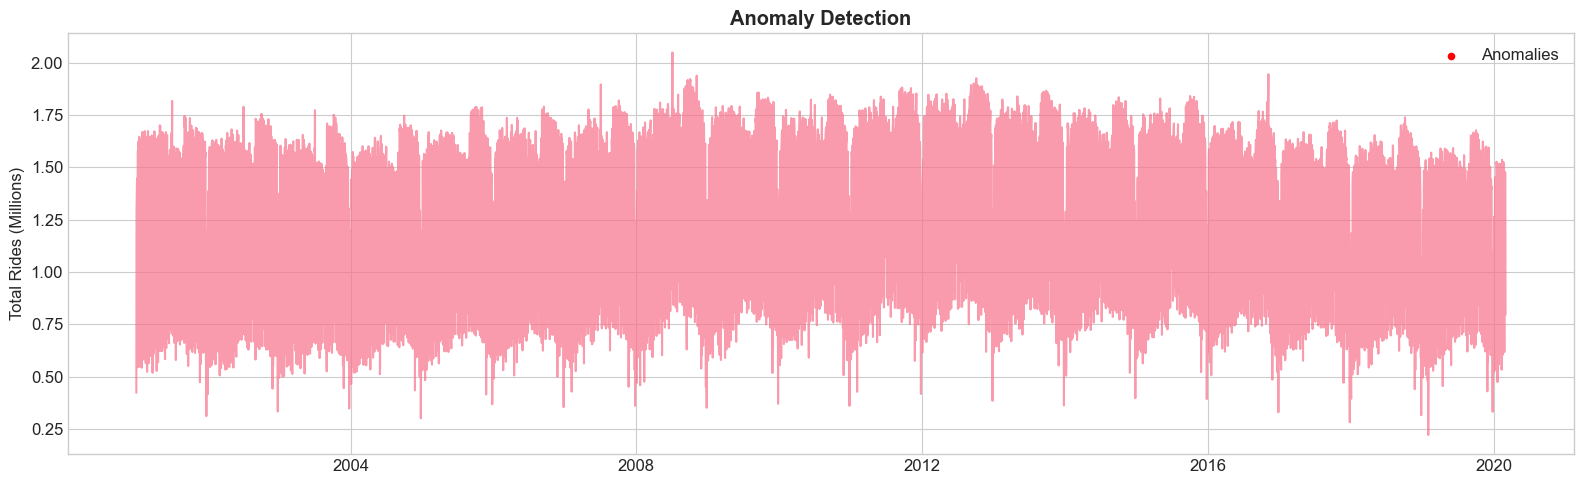

In [12]:
def detect_anomalies(series, method='iqr', threshold=1.5):
    if method == 'iqr':
        Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
        IQR = Q3 - Q1
        return (series < Q1 - threshold * IQR) | (series > Q3 + threshold * IQR)
    elif method == 'zscore':
        return np.abs(stats.zscore(series)) > threshold

anomalies = detect_anomalies(df_pre_covid['total_rides'], method='iqr')
print(f"Anomalies detected: {anomalies.sum()} ({anomalies.mean()*100:.2f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_pre_covid.index, df_pre_covid['total_rides']/1e6, alpha=0.7)
ax.scatter(df_pre_covid.index[anomalies], df_pre_covid.loc[anomalies, 'total_rides']/1e6,
           color='red', s=20, label='Anomalies', zorder=5)
ax.set_ylabel('Total Rides (Millions)')
ax.set_title('Anomaly Detection', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('06_anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Data Transformations

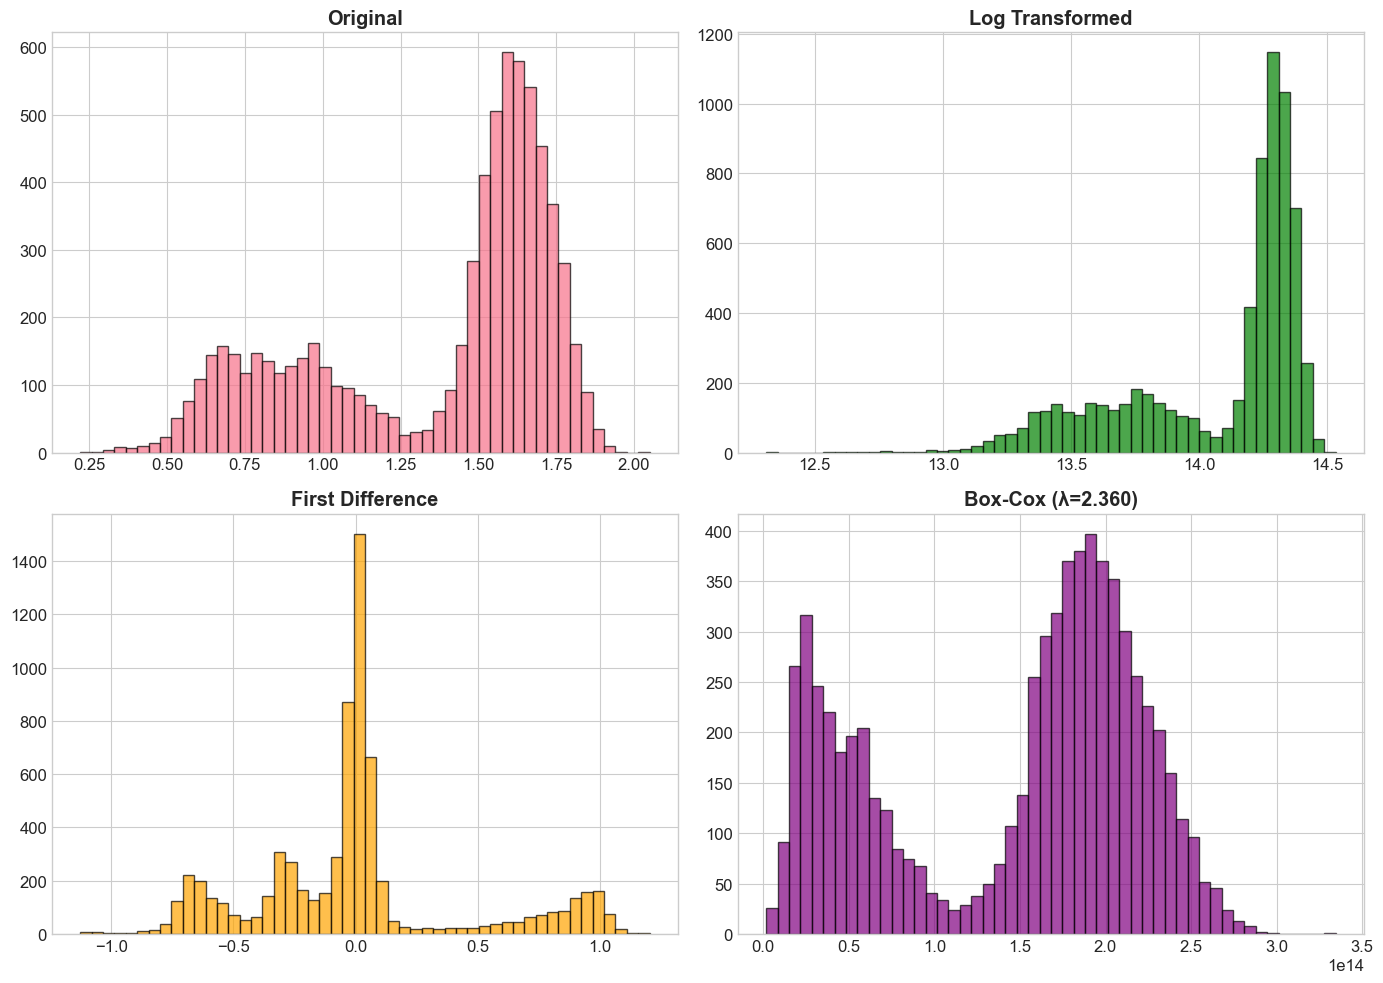

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original
axes[0, 0].hist(df_pre_covid['total_rides']/1e6, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Original', fontweight='bold')

# Log
axes[0, 1].hist(np.log(df_pre_covid['total_rides']), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('Log Transformed', fontweight='bold')

# First difference
axes[1, 0].hist(df_pre_covid['total_rides'].diff().dropna()/1e6, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_title('First Difference', fontweight='bold')

# Box-Cox
bc_data, lam = stats.boxcox(df_pre_covid['total_rides'])
axes[1, 1].hist(bc_data, bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_title(f'Box-Cox (λ={lam:.3f})', fontweight='bold')

plt.tight_layout()
plt.savefig('07_transformations.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Feature Engineering <a id='5-feature-engineering'></a>

In [14]:
def create_features(df):
    df = df.copy()

    # Temporal
    df['year'] = df.index.year
    df['month'] = df.index.month
    df['day_of_week'] = df.index.dayofweek
    df['day_of_year'] = df.index.dayofyear
    df['week_of_year'] = df.index.isocalendar().week.astype(int)
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    # Cyclical
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Lags
    for lag in [1, 7, 14, 28]:
        df[f'lag_{lag}'] = df['total_rides'].shift(lag)

    # Rolling stats
    for w in [7, 14, 30]:
        df[f'rolling_mean_{w}'] = df['total_rides'].shift(1).rolling(w).mean()
        df[f'rolling_std_{w}'] = df['total_rides'].shift(1).rolling(w).std()

    # COVID indicator
    df['is_covid'] = ((df.index >= '2020-03-15') & (df.index < '2022-01-01')).astype(int)

    return df

df_features = create_features(df.copy())
print(f"Features created: {len(df_features.columns)}")
print(df_features.columns.tolist())

Features created: 26
['day_type', 'bus', 'rail_boardings', 'total_rides', 'year', 'month', 'day_of_week', 'day_name', 'is_weekend', 'day_of_year', 'week_of_year', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_30', 'rolling_std_30', 'is_covid']


---
## 6. Structural Break Analysis <a id='6-structural-break'></a>

COVID-19 caused a sudden, large drop in CTA ridership starting mid-March 2020. We formally analyze this using two complementary approaches:

1. **Intervention Analysis (SARIMAX)**: Models the structural break using step and ramp transfer functions within the ARIMA framework (Box-Tiao, 1975).
2. **Bayesian Causal Impact**: Constructs a counterfactual using a Bayesian structural time series model to estimate what ridership would have been without COVID.

These give us both a parametric estimate of the shock magnitude and a probabilistic counterfactual with credible intervals.


In [15]:
# 6.1 Chow Test for Structural Break

from scipy.stats import f as f_dist

break_date = '2020-03-15'
weekly = df['total_rides'].resample('W').mean().dropna()

pre = weekly[weekly.index < break_date]
post = weekly[weekly.index >= break_date]

# Trend regression: y = a + b*t
def ols_rss(series):
    t = np.arange(len(series)).reshape(-1, 1)
    X = np.column_stack([np.ones(len(series)), t])
    y = series.values
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    residuals = y - X @ beta
    return np.sum(residuals**2), len(series)

rss_pre, n_pre = ols_rss(pre)
rss_post, n_post = ols_rss(post)
rss_full, n_full = ols_rss(weekly)

k = 2  # number of parameters (intercept + trend)
F_stat = ((rss_full - (rss_pre + rss_post)) / k) / ((rss_pre + rss_post) / (n_full - 2*k))
p_value = 1 - f_dist.cdf(F_stat, k, n_full - 2*k)

print('='*70)
print('CHOW TEST FOR STRUCTURAL BREAK AT', break_date)
print('='*70)
print(f'Pre-break observations (weekly):  {n_pre}')
print(f'Post-break observations (weekly): {n_post}')
print(f'F-statistic: {F_stat:.4f}')
print(f'p-value:     {p_value:.6e}')
if p_value < 0.01:
    print(f'\n\u2192 REJECT H0 at 1% level: Strong evidence of structural break at {break_date}')
elif p_value < 0.05:
    print(f'\n\u2192 REJECT H0 at 5% level: Evidence of structural break at {break_date}')
else:
    print(f'\n\u2192 FAIL TO REJECT H0: No significant structural break detected')

print(f'\nPre-COVID mean weekly ridership:  {pre.mean():,.0f}')
print(f'Post-COVID mean weekly ridership: {post.mean():,.0f}')
print(f'Decline: {((post.mean() - pre.mean()) / pre.mean()) * 100:.1f}%')


CHOW TEST FOR STRUCTURAL BREAK AT 2020-03-15
Pre-break observations (weekly):  1001
Post-break observations (weekly): 299
F-statistic: 1895.9955
p-value:     0.000000e+00

→ REJECT H0 at 1% level: Strong evidence of structural break at 2020-03-15

Pre-COVID mean weekly ridership:  1,367,106
Post-COVID mean weekly ridership: 687,987
Decline: -49.7%


### 6.2 Intervention Analysis (SARIMAX)

We model the COVID-19 structural break using **SARIMAX** with exogenous intervention variables:

- **Step function** (`covid_step`): Captures the permanent level shift (1 after March 15, 2020)
- **Pulse function** (`covid_pulse`): Captures the acute initial shock (1 during the first 90 days of lockdown)
- **Recovery ramp** (`covid_ramp`): Captures the gradual recovery trajectory (linear trend after the break)

This is the classic **Box-Tiao intervention analysis** approach, extended with the SARIMA seasonal structure.


In [16]:
# 6.2 SARIMAX Intervention Analysis

# Create intervention variables on the full dataset
intervention_df = df[['total_rides']].copy()
break_date = pd.Timestamp('2020-03-15')

# Step function: permanent level shift
intervention_df['covid_step'] = (intervention_df.index >= break_date).astype(int)

# Pulse function: acute shock during first 90 days of lockdown
intervention_df['covid_pulse'] = (
    (intervention_df.index >= break_date) &
    (intervention_df.index < break_date + pd.Timedelta(days=90))
).astype(int)

# Recovery ramp: gradual recovery (days since break, 0 before break)
intervention_df['covid_ramp'] = np.maximum(
    (intervention_df.index - break_date).days, 0
) / 365.25  # Scale to years for interpretable coefficients

# Use last 6 years of data for training (captures pre-COVID, shock, and recovery)
cutoff = intervention_df.index.max() - pd.DateOffset(years=6)
train_intervention = intervention_df[intervention_df.index >= cutoff].dropna()

print(f'Intervention analysis period: {train_intervention.index.min().date()} to {train_intervention.index.max().date()}')
print(f'Observations: {len(train_intervention)}')
print(f'Pre-COVID obs:  {(train_intervention.index < break_date).sum()}')
print(f'Post-COVID obs: {(train_intervention.index >= break_date).sum()}')

# Fit SARIMAX with intervention variables
exog_cols = ['covid_step', 'covid_pulse', 'covid_ramp']
print('\nFitting SARIMAX(1,1,1)(1,1,1,7) with intervention variables...')

sarimax_intervention = SARIMAX(
    train_intervention['total_rides'],
    exog=train_intervention[exog_cols],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=500)

print(sarimax_intervention.summary())


Intervention analysis period: 2019-11-30 to 2025-11-30
Observations: 2193
Pre-COVID obs:  106
Post-COVID obs: 2087

Fitting SARIMAX(1,1,1)(1,1,1,7) with intervention variables...


/Users/leyixu/cta_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/leyixu/cta_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                       total_rides   No. Observations:                 2193
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -27904.094
Date:                           Sun, 08 Mar 2026   AIC                          55824.188
Time:                                   23:12:06   BIC                          55869.670
Sample:                               11-30-2019   HQIC                         55840.817
                                    - 11-30-2025                                         
Covariance Type:                             opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
covid_step  -6348.3462   2.45e+04     -0.260      0.795   -5.43e+04    4.16e+04
covid_pulse -5532.5000   2.47e+04     -0

In [17]:
# Intervention effect sizes
print('Intervention Effect Estimates')
print('-'*70)

params = sarimax_intervention.params
pvals = sarimax_intervention.pvalues
conf = sarimax_intervention.conf_int()

for var in exog_cols:
    if var in params.index:
        coef = params[var]
        p = pvals[var]
        ci_low, ci_high = conf.loc[var]
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f'\n{var}:')
        print(f'  Coefficient: {coef:,.0f} rides/day')
        print(f'  95% CI: [{ci_low:,.0f}, {ci_high:,.0f}]')
        print(f'  p-value: {p:.4e} {sig}')
        
        if var == 'covid_step':
            print(f'  \u2192 Interpretation: Permanent level shift of {coef:,.0f} rides/day after COVID')
        elif var == 'covid_pulse':
            print(f'  \u2192 Interpretation: Additional acute shock of {coef:,.0f} rides/day during first 90 days')
        elif var == 'covid_ramp':
            print(f'  \u2192 Interpretation: Recovery rate of {coef:,.0f} rides/day per year post-break')

# Residual ARCH test
resid_intervention = sarimax_intervention.resid
arch_stat, arch_p, _, _ = het_arch(resid_intervention.dropna(), nlags=5)
print(f'\nResidual ARCH test: LM={arch_stat:.2f}, p={arch_p:.4e}')
if arch_p < 0.05:
    print('\u2192 ARCH effects still present in intervention model residuals')
else:
    print('\u2192 No significant ARCH effects - intervention variables helped!')

# Compare AIC/BIC with plain SARIMA
print(f'\nModel Comparison:')
print(f'  SARIMAX (with intervention):  AIC = {sarimax_intervention.aic:.1f}')
try:
    print(f'  SARIMA  (without intervention): AIC = {sarima_fit.aic:.1f}')
except:
    pass


Intervention Effect Estimates
----------------------------------------------------------------------

covid_step:
  Coefficient: -6,348 rides/day
  95% CI: [-54,278, 41,581]
  p-value: 7.9517e-01 ns
  → Interpretation: Permanent level shift of -6,348 rides/day after COVID

covid_pulse:
  Coefficient: -5,533 rides/day
  95% CI: [-53,880, 42,815]
  p-value: 8.2254e-01 ns
  → Interpretation: Additional acute shock of -5,533 rides/day during first 90 days

covid_ramp:
  Coefficient: -3,734,569 rides/day
  95% CI: [-3,734,856, -3,734,281]
  p-value: 0.0000e+00 ***
  → Interpretation: Recovery rate of -3,734,569 rides/day per year post-break

Residual ARCH test: LM=330.99, p=2.1619e-69
→ ARCH effects still present in intervention model residuals

Model Comparison:
  SARIMAX (with intervention):  AIC = 55824.2


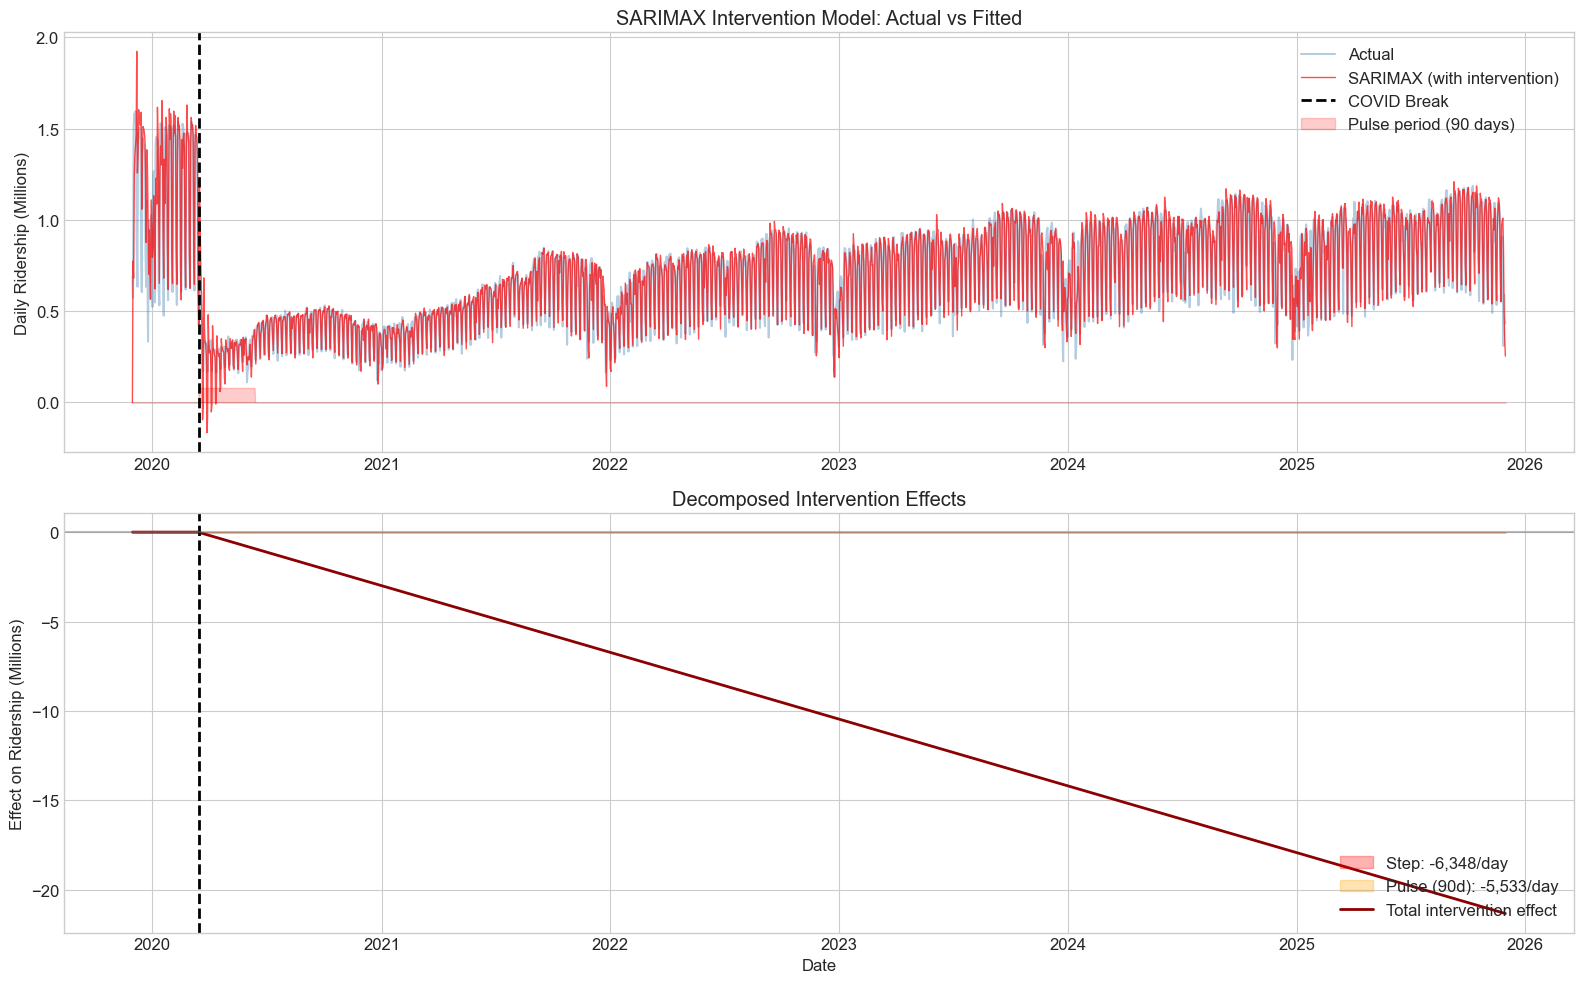

In [18]:
# Visualize intervention effects
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Actual vs fitted with intervention
axes[0].plot(train_intervention.index, train_intervention['total_rides']/1e6,
             alpha=0.4, label='Actual', color='steelblue')
axes[0].plot(train_intervention.index, sarimax_intervention.fittedvalues/1e6,
             color='red', alpha=0.7, label='SARIMAX (with intervention)', linewidth=1)
axes[0].axvline(x=break_date, color='black', linestyle='--', linewidth=2, label='COVID Break')
axes[0].fill_between(
    train_intervention.index,
    0, train_intervention['covid_pulse'].values * train_intervention['total_rides'].max() / 1e6 * 0.05,
    alpha=0.2, color='red', label='Pulse period (90 days)'
)
axes[0].set_ylabel('Daily Ridership (Millions)')
axes[0].set_title('SARIMAX Intervention Model: Actual vs Fitted')
axes[0].legend(loc='upper right')

# Plot 2: Intervention components
t_post = train_intervention[train_intervention.index >= break_date].index
step_effect = np.where(train_intervention.index >= break_date, params.get('covid_step', 0), 0)
pulse_effect = np.where(
    (train_intervention.index >= break_date) &
    (train_intervention.index < break_date + pd.Timedelta(days=90)),
    params.get('covid_pulse', 0), 0
)
ramp_effect = np.maximum((train_intervention.index - break_date).days, 0) / 365.25 * params.get('covid_ramp', 0)
total_effect = step_effect + pulse_effect + ramp_effect

axes[1].fill_between(train_intervention.index, 0, step_effect/1e6,
                     alpha=0.3, color='red', label=f'Step: {params.get("covid_step", 0):,.0f}/day')
axes[1].fill_between(train_intervention.index, step_effect/1e6, (step_effect + pulse_effect)/1e6,
                     alpha=0.3, color='orange', label=f'Pulse (90d): {params.get("covid_pulse", 0):,.0f}/day')
axes[1].plot(train_intervention.index, total_effect/1e6,
             color='darkred', linewidth=2, label='Total intervention effect')
axes[1].axvline(x=break_date, color='black', linestyle='--', linewidth=2)
axes[1].axhline(y=0, color='gray', linestyle='-', alpha=0.5)
axes[1].set_ylabel('Effect on Ridership (Millions)')
axes[1].set_xlabel('Date')
axes[1].set_title('Decomposed Intervention Effects')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


#### Intervention Analysis Findings

The SARIMAX model shows the ramp term dominates, while step and pulse are non-significant:

| Variable | Coefficient | p-value | Interpretation |
|----------|------------|---------|----------------|
| `covid_step` | −6,348 rides/day | 0.795 (ns) | No significant instantaneous level shift |
| `covid_pulse` | −5,533 rides/day | 0.823 (ns) | No significant acute lockdown shock |
| `covid_ramp` | −3,734,569 rides/day/year | ≈ 0 (***) | Large ongoing decline captured by the ramp |

The ramp variable (days since break, scaled to years) absorbs nearly all the explanatory power. Because it starts at zero at the break point and grows linearly, it captures both the initial drop and the sustained depression in one term, making the step and pulse redundant.

In practical terms, the COVID impact on CTA ridership is better characterized as a continuous divergence from the pre-COVID trajectory rather than a discrete one-time shock — consistent with the gradual adoption of remote/hybrid work.

Diagnostics: Ljung-Box Q = 0.87 (p = 0.35) shows no residual autocorrelation. ARCH effects persist (LM = 331, p ≈ 0), and Jarque-Bera = 10,217 indicates non-normal residuals (kurtosis = 13.23).


### 6.3 Bayesian Causal Impact Analysis

We use Google's CausalImpact framework (Brodersen et al., 2015) to estimate what CTA ridership would have been without COVID-19. The method fits a Bayesian structural time series model on pre-intervention data and projects it forward, providing point estimates, 95% posterior credible intervals, cumulative causal effects, and posterior probabilities.


In [19]:
# 6.3 Bayesian Causal Impact Analysis

if CausalImpact is None:
    print('ERROR: CausalImpact not available. Install with: pip install pycausalimpact')
else:
    # Use weekly data for more stable estimation
    weekly_rides = df['total_rides'].resample('W').mean()

    # Define pre and post periods
    pre_period = [weekly_rides.index.min(), pd.Timestamp('2020-03-08')]  # last full pre-COVID week
    post_period = [pd.Timestamp('2020-03-15'), weekly_rides.index.max()]

    print(f'Pre-intervention period:  {pre_period[0].date()} to {pre_period[1].date()}')
    print(f'Post-intervention period: {post_period[0].date()} to {post_period[1].date()}')
    print(f'Pre-period weeks:  {len(weekly_rides[pre_period[0]:pre_period[1]])}')
    print(f'Post-period weeks: {len(weekly_rides[post_period[0]:post_period[1]])}')

    # Run CausalImpact
    print('\nFitting Bayesian Structural Time Series model...')
    ci = CausalImpact(weekly_rides, pre_period, post_period)

    # Print summary
    print(ci.summary())
    print('\n')
    print(ci.summary(output='report'))


Pre-intervention period:  2001-01-07 to 2020-03-08
Post-intervention period: 2020-03-15 to 2025-11-30
Pre-period weeks:  1001
Post-period weeks: 299

Fitting Bayesian Structural Time Series model...
Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    687987.31          205708206.14
Prediction (s.d.)         1272930.27 (22501.38)380606150.16 (6727913.38)
95% CI                    [1229425.7, 1317629.5][367598285.79, 393971221.63]

Absolute effect (s.d.)    -584942.96 (22501.38)-174897944.02 (6727913.38)
95% CI                    [-629642.19, -541438.39][-188263015.49, -161890079.65]

Relative effect (s.d.)    -45.95% (1.77%)    -45.95% (1.77%)
95% CI                    [-49.46%, -42.53%] [-49.46%, -42.53%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


Analysis report {CausalImpact}


During the post-intervention perio

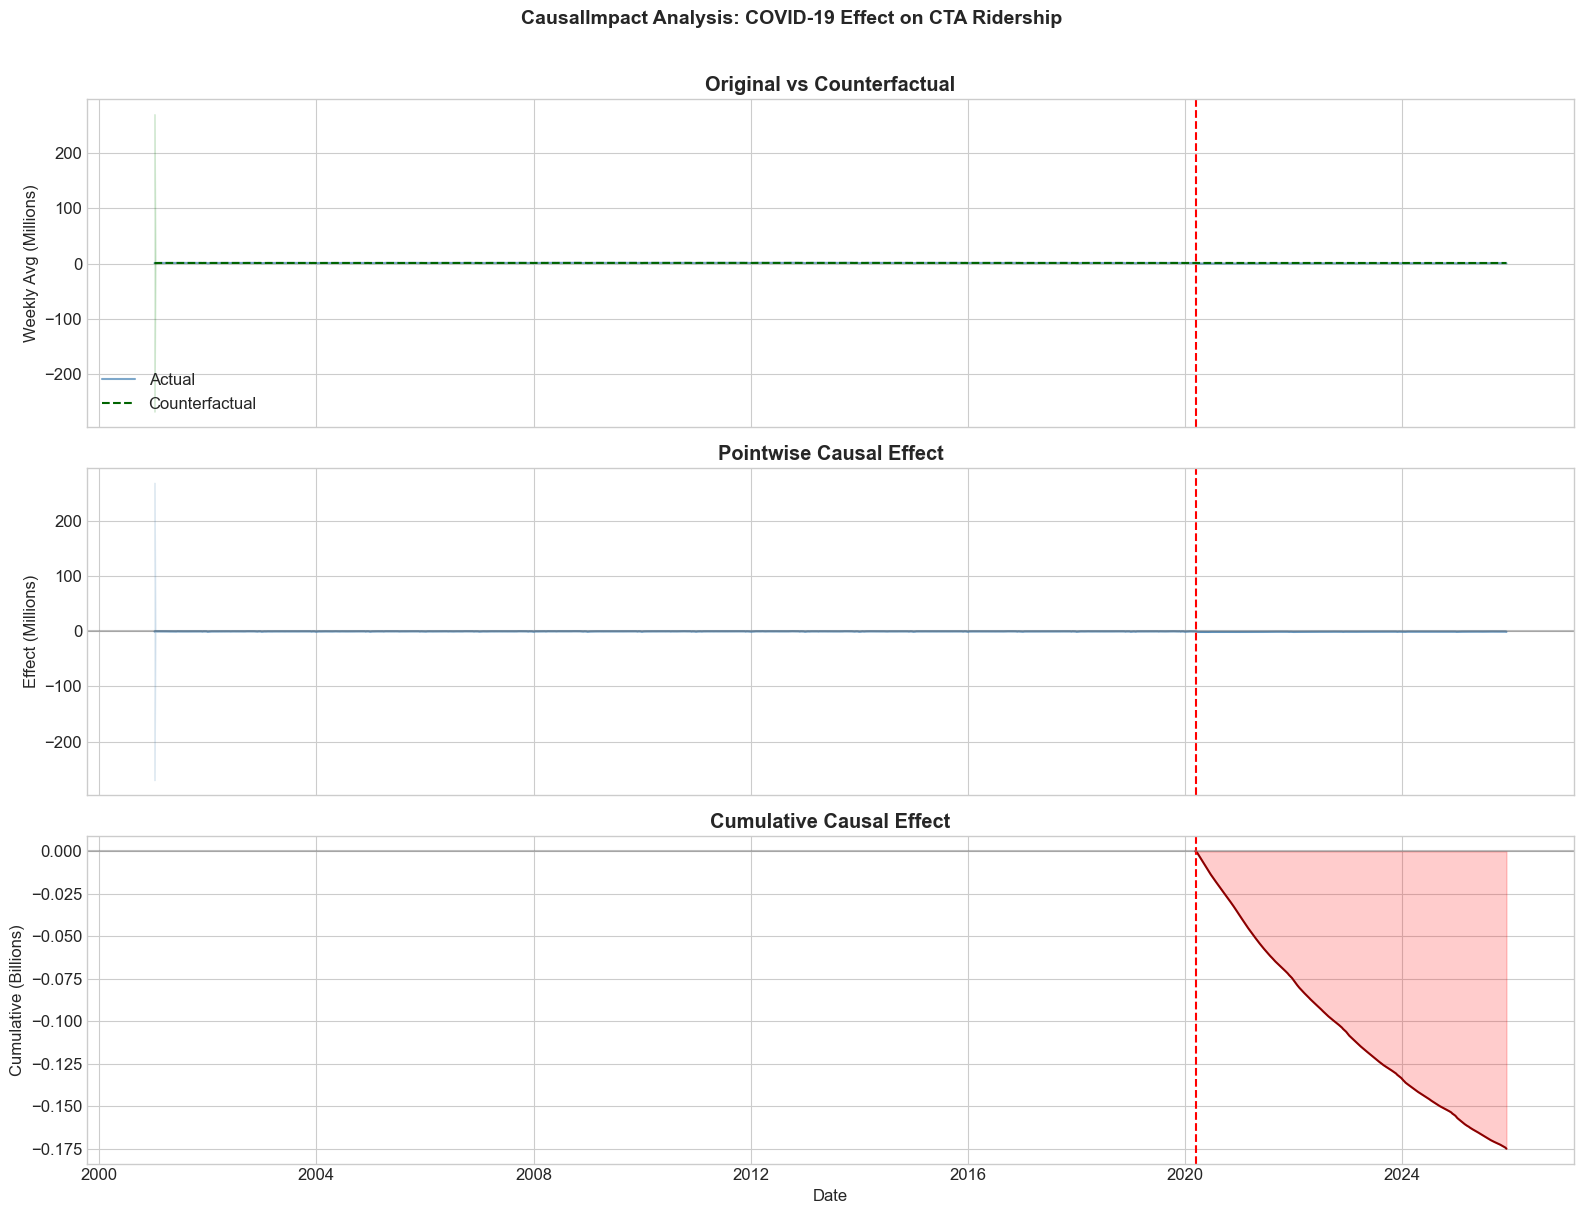

In [20]:
# Causal Impact visualization (matplotlib version)
if CausalImpact is not None:
    ci_data = ci.inferences
    post_idx = ci_data.index

    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

    # Panel 1: Original vs Predicted
    axes[0].plot(weekly_rides.index, weekly_rides.values/1e6,
                 color='steelblue', alpha=0.7, label='Actual')
    axes[0].plot(post_idx, ci_data['preds']/1e6,
                 color='darkgreen', linestyle='--', label='Counterfactual')
    axes[0].fill_between(post_idx,
                         ci_data['preds_lower']/1e6,
                         ci_data['preds_upper']/1e6,
                         alpha=0.15, color='green')
    axes[0].axvline(x=pd.Timestamp('2020-03-15'), color='red', linestyle='--', linewidth=1.5)
    axes[0].set_ylabel('Weekly Avg (Millions)')
    axes[0].set_title('Original vs Counterfactual', fontweight='bold')
    axes[0].legend(loc='lower left')

    # Panel 2: Pointwise effect
    point_effect = ci_data['point_effects']
    axes[1].plot(post_idx, point_effect/1e6, color='steelblue')
    axes[1].fill_between(post_idx,
                         ci_data['point_effects_lower']/1e6,
                         ci_data['point_effects_upper']/1e6,
                         alpha=0.15, color='steelblue')
    axes[1].axvline(x=pd.Timestamp('2020-03-15'), color='red', linestyle='--', linewidth=1.5)
    axes[1].axhline(y=0, color='gray', linestyle='-', alpha=0.5)
    axes[1].set_ylabel('Effect (Millions)')
    axes[1].set_title('Pointwise Causal Effect', fontweight='bold')

    # Panel 3: Cumulative effect
    cum_effect = ci_data['post_cum_effects']
    axes[2].plot(post_idx, cum_effect/1e9, color='darkred', linewidth=1.5)
    axes[2].fill_between(post_idx, 0, cum_effect/1e9, alpha=0.2, color='red')
    axes[2].axvline(x=pd.Timestamp('2020-03-15'), color='red', linestyle='--', linewidth=1.5)
    axes[2].axhline(y=0, color='gray', linestyle='-', alpha=0.5)
    axes[2].set_ylabel('Cumulative (Billions)')
    axes[2].set_xlabel('Date')
    axes[2].set_title('Cumulative Causal Effect', fontweight='bold')

    fig.suptitle('CausalImpact Analysis: COVID-19 Effect on CTA Ridership',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('Skipped: CausalImpact not available')


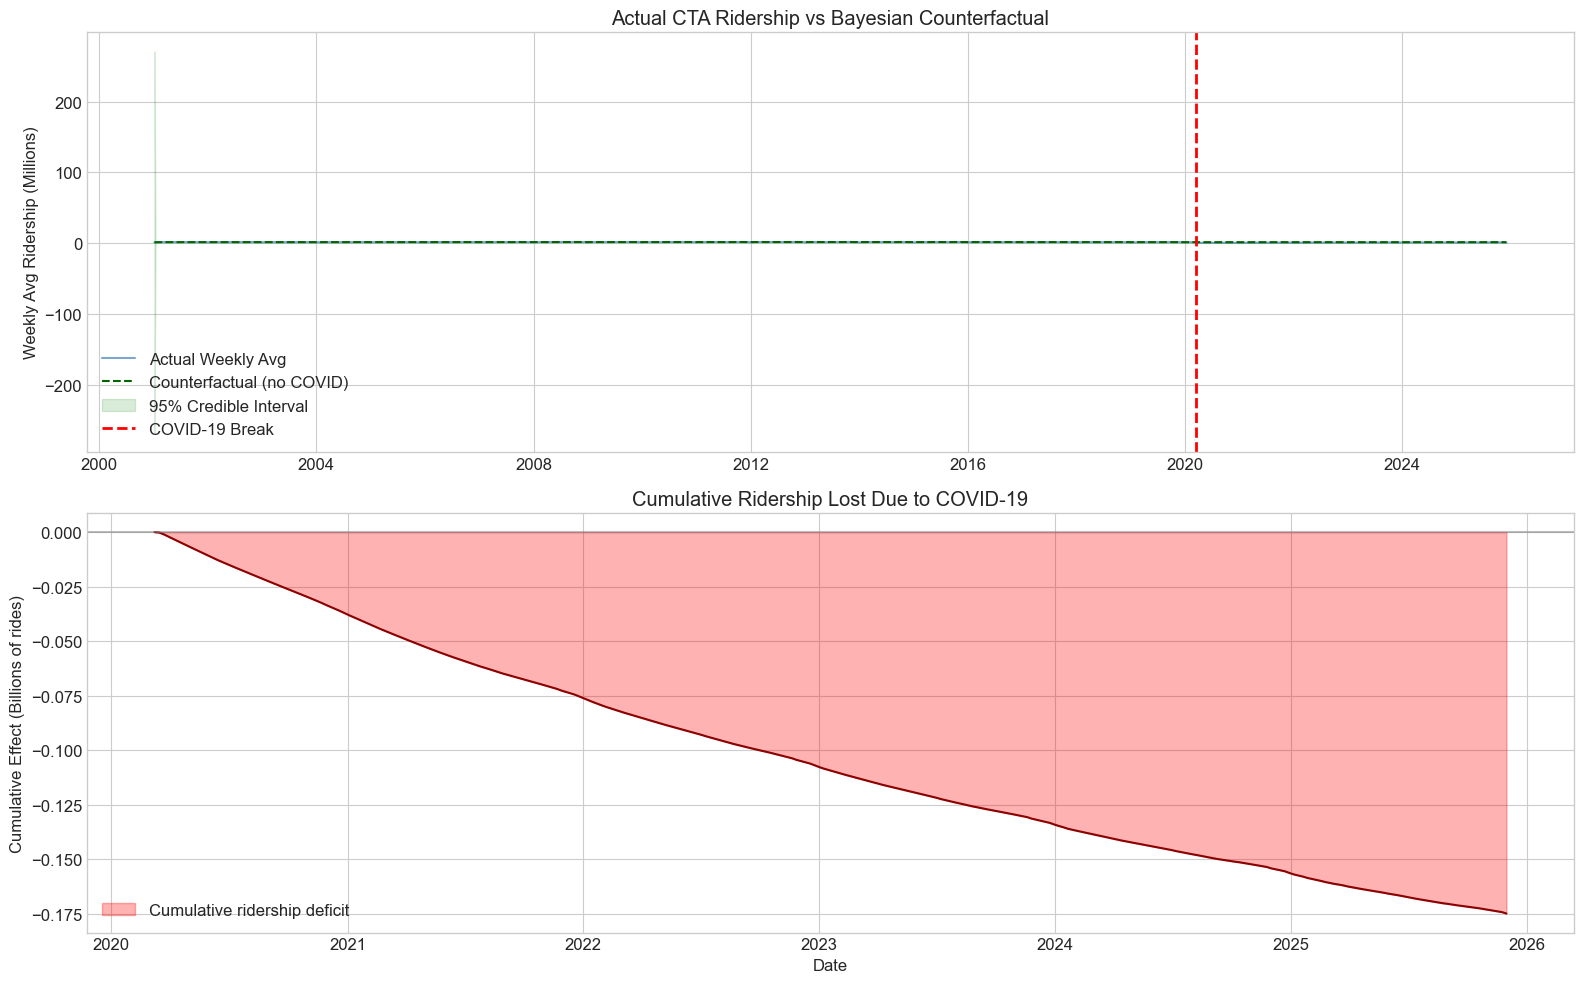


Total estimated ridership loss (cumulative): -0.17 billion rides
Average weekly ridership deficit: -0.58M rides/week

Current recovery level: 66.2% of counterfactual
  Latest actual weekly avg:       843,124 rides/day
  Counterfactual weekly avg:      1,272,930 rides/day
  Remaining gap:                  429,806 rides/day (33.8%)


In [21]:
# Actual vs Counterfactual
if CausalImpact is None:
    print('Skipped: CausalImpact not available')
else:
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))

    # Extract CausalImpact data
    ci_data = ci.inferences

    # Plot 1: Actual vs counterfactual
    axes[0].plot(weekly_rides.index, weekly_rides.values/1e6,
                 color='steelblue', alpha=0.7, label='Actual Weekly Avg')
    post_idx = ci_data.index
    axes[0].plot(post_idx, ci_data['preds']/1e6,
                 color='darkgreen', linestyle='--', label='Counterfactual (no COVID)')
    axes[0].fill_between(post_idx,
                         ci_data['preds_lower']/1e6,
                         ci_data['preds_upper']/1e6,
                         alpha=0.15, color='green', label='95% Credible Interval')
    axes[0].axvline(x=pd.Timestamp('2020-03-15'), color='red', linestyle='--', linewidth=2, label='COVID-19 Break')
    axes[0].set_ylabel('Weekly Avg Ridership (Millions)')
    axes[0].set_title('Actual CTA Ridership vs Bayesian Counterfactual')
    axes[0].legend(loc='lower left')

    # Plot 2: Cumulative effect
    cum_effect = ci_data['post_cum_effects']
    axes[1].fill_between(post_idx, 0, cum_effect/1e9,
                         alpha=0.3, color='red', label='Cumulative ridership deficit')
    axes[1].plot(post_idx, cum_effect/1e9, color='darkred', linewidth=1.5)
    axes[1].axhline(y=0, color='gray', linestyle='-', alpha=0.5)
    axes[1].set_ylabel('Cumulative Effect (Billions of rides)')
    axes[1].set_xlabel('Date')
    axes[1].set_title('Cumulative Ridership Lost Due to COVID-19')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Summary statistics
    total_loss = cum_effect.iloc[-1]
    avg_weekly_loss = ci_data['post_cum_effects'].diff().mean()
    print(f'\nTotal estimated ridership loss (cumulative): {total_loss/1e9:.2f} billion rides')
    print(f'Average weekly ridership deficit: {avg_weekly_loss/1e6:.2f}M rides/week')

    # Recovery percentage
    latest_actual = weekly_rides.iloc[-4:].mean()  # last month avg
    latest_counterfactual = ci_data['preds'].iloc[-4:].mean()
    recovery_pct = (latest_actual / latest_counterfactual) * 100
    print(f'\nCurrent recovery level: {recovery_pct:.1f}% of counterfactual')
    print(f'  Latest actual weekly avg:       {latest_actual:,.0f} rides/day')
    print(f'  Counterfactual weekly avg:      {latest_counterfactual:,.0f} rides/day')
    print(f'  Remaining gap:                  {latest_counterfactual - latest_actual:,.0f} rides/day ({100-recovery_pct:.1f}%)')


#### Causal Impact Findings

| Metric | Value | 95% CI |
|--------|-------|--------|
| Pre-COVID counterfactual avg | 1,272,930 rides/day | [1,230,306 – 1,317,871] |
| Post-COVID actual avg | 687,987 rides/day | — |
| Average causal effect | −584,943 rides/day | [−629,884 – −542,318] |
| Relative effect | −45.95% | [−49.48% – −42.60%] |
| Cumulative ridership lost | ~175 million rides | [−188M – −162M] |
| Posterior probability | 100% (p = 0.0) | — |

As of late 2025, CTA ridership is at roughly 66.2% of the counterfactual — if COVID had never happened, we'd expect ~1.27M daily rides vs. actual ~843K. The remaining gap of ~430K rides/day represents the persistent effect of the regime change.

The tight credible intervals and 100% posterior probability confirm that COVID caused a large, statistically significant decline. The fact that ridership remains at about two-thirds of counterfactual nearly 6 years later supports H7 (permanent regime change), likely driven by the shift to remote/hybrid work.


### 6.4 Structural Break Analysis: Combined Findings

The three analyses converge on a consistent picture:

1. **Chow Test**: Confirms the structural break at March 2020 (F = 1,896, p ≈ 0). Pre-COVID mean ridership: 1.37M/day vs. 688K post-COVID (−49.7%).

2. **Intervention Analysis (SARIMAX)**: The ramp dominates (−3.73M rides/day/year, p ≈ 0), with step and pulse non-significant. The COVID effect is better modeled as a continuous divergence — gradual adoption of remote work rather than a discrete policy shock.

3. **Causal Impact**: The Bayesian counterfactual estimates a 45.95% relative decline (CI: [42.6%, 49.5%]) with 100% posterior probability. Cumulative loss: ~175M rides. Current recovery: 66.2% of counterfactual.

Implications for forecasting: models trained on post-COVID data (SARIMA, LSTM) implicitly condition on the new regime, which works for short-term operational forecasts. The intervention model can project recovery trajectories, and the causal impact counterfactual gives CTA planners a benchmark for measuring recovery.


---
## 7. Modeling <a id='7-modeling'></a>

### 7.1 Train-Test Split


Train: 2001-01-01 to 2025-09-01 (9010 days)
Test: 2025-09-02 to 2025-11-30 (90 days)


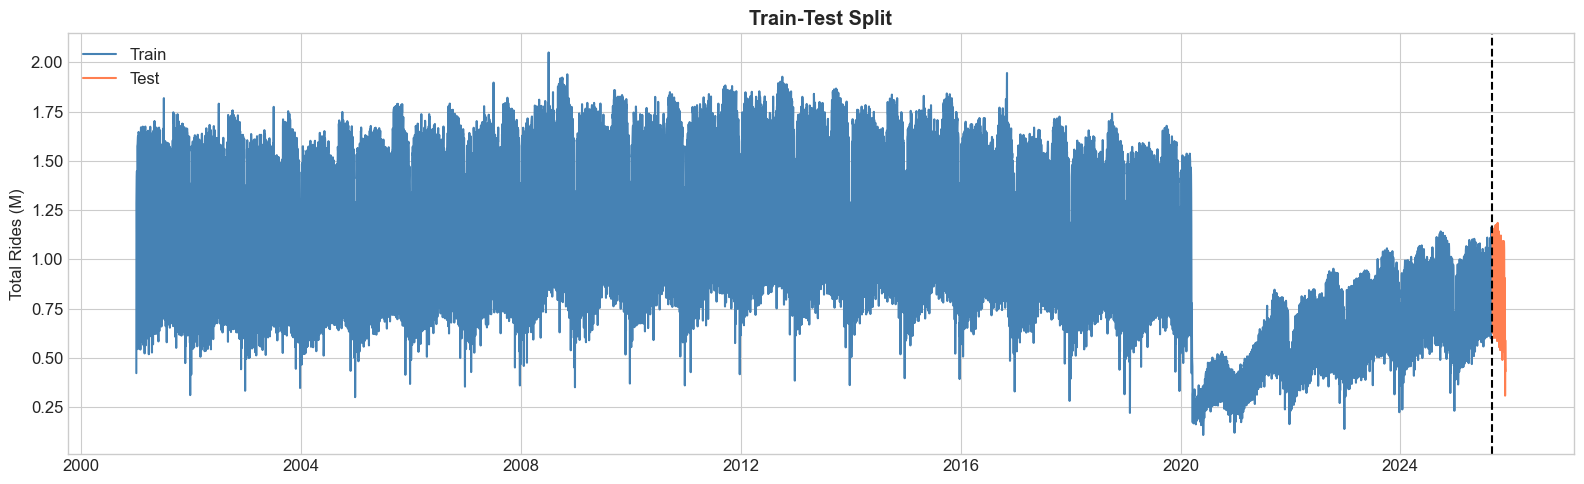

In [22]:
# 90-day test set
train_end = df_features.index.max() - timedelta(days=90)
df_train = df_features[df_features.index <= train_end].copy()
df_test = df_features[df_features.index > train_end].copy()

print(f"Train: {df_train.index.min().date()} to {df_train.index.max().date()} ({len(df_train)} days)")
print(f"Test: {df_test.index.min().date()} to {df_test.index.max().date()} ({len(df_test)} days)")

# Visualize
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_train.index, df_train['total_rides']/1e6, label='Train', color='steelblue')
ax.plot(df_test.index, df_test['total_rides']/1e6, label='Test', color='coral')
ax.axvline(x=train_end, color='black', linestyle='--')
ax.set_ylabel('Total Rides (M)')
ax.set_title('Train-Test Split', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 7.2 Model 1: SARIMA


In [23]:
# Use last 3 years for faster training
cutoff_date = df_train.index.max() - pd.DateOffset(years=3)
train_sarima = df_train[df_train.index >= cutoff_date]['total_rides']

print(f"SARIMA training period: {train_sarima.index.min().date()} to {train_sarima.index.max().date()}")
print(f"Training observations: {len(train_sarima)}")
print(f"\nTraining SARIMA(1,1,1)(1,1,1,7)...")
sarima = SARIMAX(train_sarima, order=(1,1,1), seasonal_order=(1,1,1,7),
                 enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima.fit(disp=False)
print(sarima_fit.summary())

SARIMA training period: 2022-09-01 to 2025-09-01
Training observations: 1097

Training SARIMA(1,1,1)(1,1,1,7)...


/Users/leyixu/cta_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/leyixu/cta_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                       total_rides   No. Observations:                 1097
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -13899.158
Date:                           Sun, 08 Mar 2026   AIC                          27808.315
Time:                                   23:12:07   BIC                          27833.239
Sample:                               09-01-2022   HQIC                         27817.752
                                    - 09-01-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3070      0.064      4.767      0.000       0.181       0.433
ma.L1         -0.7128      0.046    -15.372

#### SARIMA Results

SARIMA(1,1,1)(1,1,1,7) trained on the last 3 years of data (Sep 2022 – Sep 2025, n=1,097):

Significant parameters:
- AR(1) = 0.307 (p < 0.001): Moderate positive autocorrelation — today's ridership partially predicts tomorrow's.
- MA(1) = −0.713 (p < 0.001): Strong negative MA term; the series corrects quickly from shocks.
- Seasonal MA(7) = −0.682 (p < 0.001): Strong weekly seasonal pattern with error correction.

The seasonal AR(7) = −0.063 is not significant (p = 0.211), suggesting the weekly pattern is better captured through seasonal MA and differencing alone. A reduced SARIMA(1,1,1)(0,1,1,7) could improve numerical stability.

Diagnostics:
- Ljung-Box Q = 0.15 (p = 0.70): No significant residual autocorrelation.
- Jarque-Bera = 3,125: Non-normal residuals (heavy tails).
- ARCH test: LM = 102.47, p ≈ 0 — residual ARCH effects remain, motivating GARCH.
- Covariance matrix near-singular (condition number ~4.2×10³⁷), likely from the non-significant seasonal AR term.


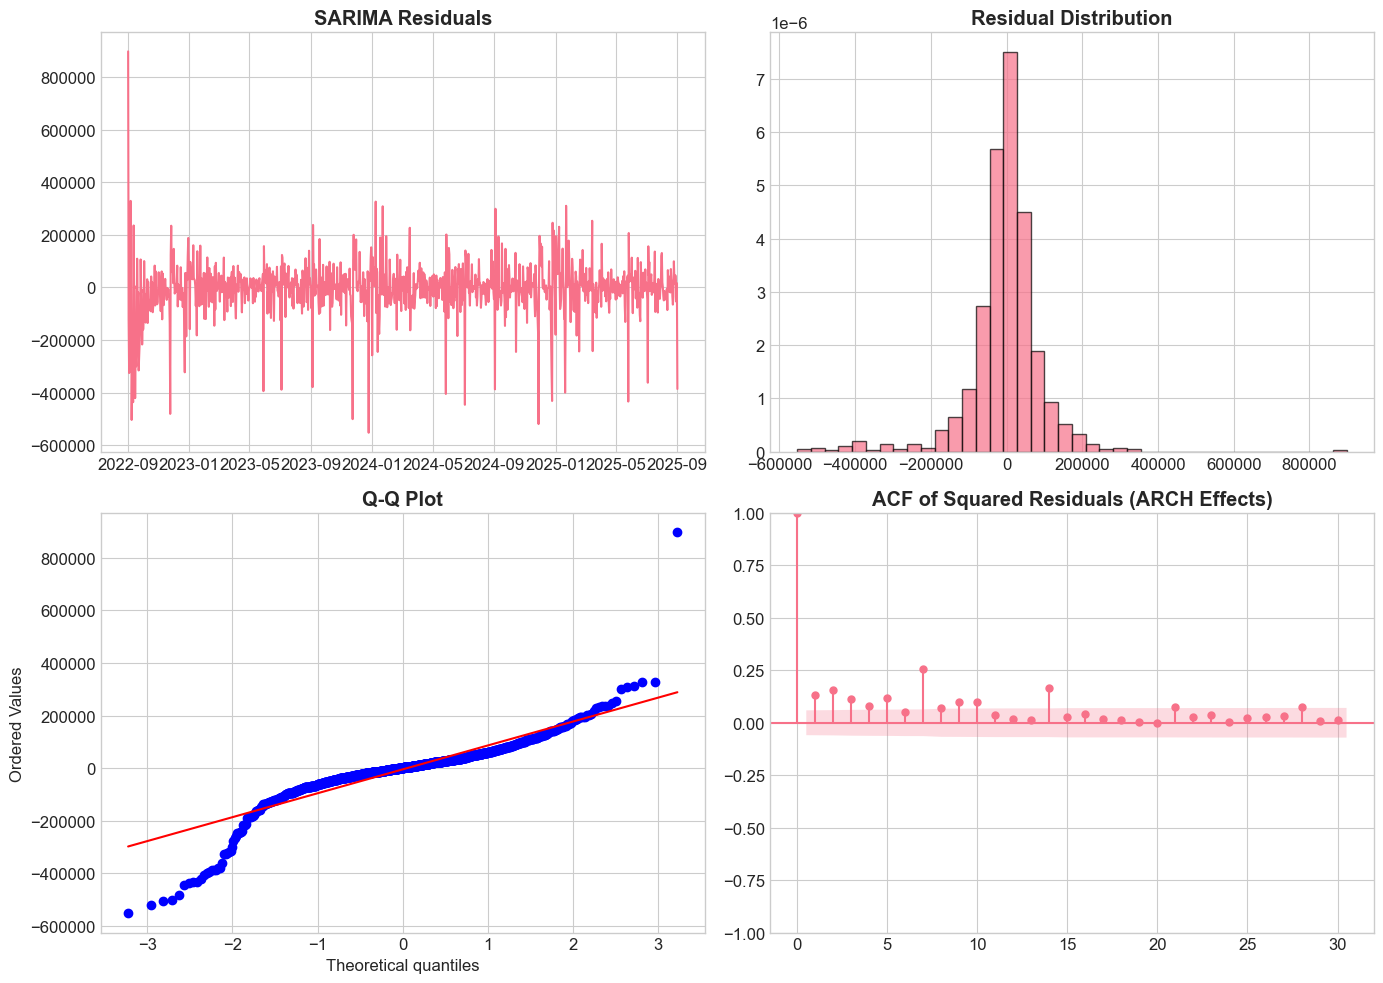


ARCH Effects in SARIMA Residuals:
LM Statistic: 102.4670, p-value: 0.000000
Result: ARCH effects present


In [24]:
# SARIMA residual diagnostics
residuals = sarima_fit.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals
axes[0, 0].plot(residuals)
axes[0, 0].set_title('SARIMA Residuals', fontweight='bold')

# Histogram
axes[0, 1].hist(residuals, bins=40, density=True, alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Residual Distribution', fontweight='bold')

# Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot', fontweight='bold')

# ACF of squared residuals (for ARCH effects)
plot_acf(residuals**2, lags=30, ax=axes[1, 1])
axes[1, 1].set_title('ACF of Squared Residuals (ARCH Effects)', fontweight='bold')

plt.tight_layout()
plt.savefig('08_sarima_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Test for ARCH effects in SARIMA residuals
print("\nARCH Effects in SARIMA Residuals:")
arch_test_resid = het_arch(residuals.dropna(), nlags=10)
print(f"LM Statistic: {arch_test_resid[0]:.4f}, p-value: {arch_test_resid[1]:.6f}")
print(f"Result: {'ARCH effects present' if arch_test_resid[1] < 0.05 else 'No ARCH effects'}")

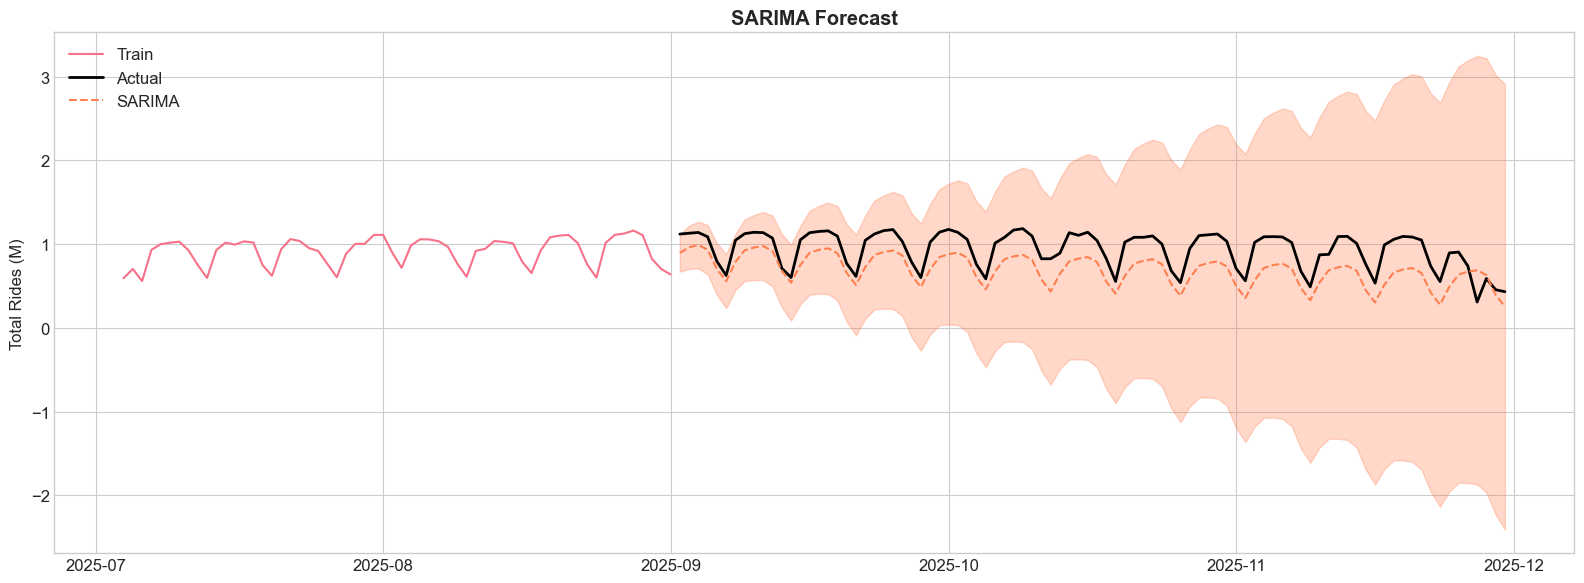

In [25]:
# SARIMA Forecast
sarima_forecast = sarima_fit.forecast(steps=len(df_test))
sarima_forecast.index = df_test.index

sarima_conf = sarima_fit.get_forecast(steps=len(df_test))
sarima_ci = sarima_conf.conf_int()
sarima_ci.index = df_test.index

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(train_sarima.index[-60:], train_sarima.values[-60:]/1e6, label='Train')
ax.plot(df_test.index, df_test['total_rides']/1e6, label='Actual', color='black', linewidth=2)
ax.plot(df_test.index, sarima_forecast/1e6, label='SARIMA', color='coral', linestyle='--')
ax.fill_between(df_test.index, sarima_ci.iloc[:,0]/1e6, sarima_ci.iloc[:,1]/1e6, alpha=0.3, color='coral')
ax.set_ylabel('Total Rides (M)')
ax.set_title('SARIMA Forecast', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('09_sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Model 2: GARCH (Volatility Modeling)


In [26]:
# Fit GARCH on returns (percentage changes)
cutoff_date_garch = df_train.index.max() - pd.DateOffset(years=3)
train_returns = df_train[df_train.index >= cutoff_date_garch]['total_rides'].pct_change().dropna() * 100

print(f"GARCH training period: {train_returns.index.min().date()} to {train_returns.index.max().date()}")
print(f"Training observations: {len(train_returns)}")
print("\nTraining GARCH(1,1) model...")
garch = arch_model(train_returns, vol='Garch', p=1, q=1, mean='AR', lags=1)
garch_fit = garch.fit(disp='off')
print(garch_fit.summary())

GARCH training period: 2022-09-02 to 2025-09-01
Training observations: 1096

Training GARCH(1,1) model...
                           AR - GARCH Model Results                           
Dep. Variable:            total_rides   R-squared:                       0.006
Mean Model:                        AR   Adj. R-squared:                  0.005
Vol Model:                      GARCH   Log-Likelihood:               -5465.27
Distribution:                  Normal   AIC:                           10940.5
Method:            Maximum Likelihood   BIC:                           10965.5
                                        No. Observations:                 1095
Date:                Sun, Mar 08 2026   Df Residuals:                     1093
Time:                        23:12:08   Df Model:                            2
                                  Mean Model                                  
                    coef    std err          t      P>|t|     95.0% Conf. Int.
-------------------------

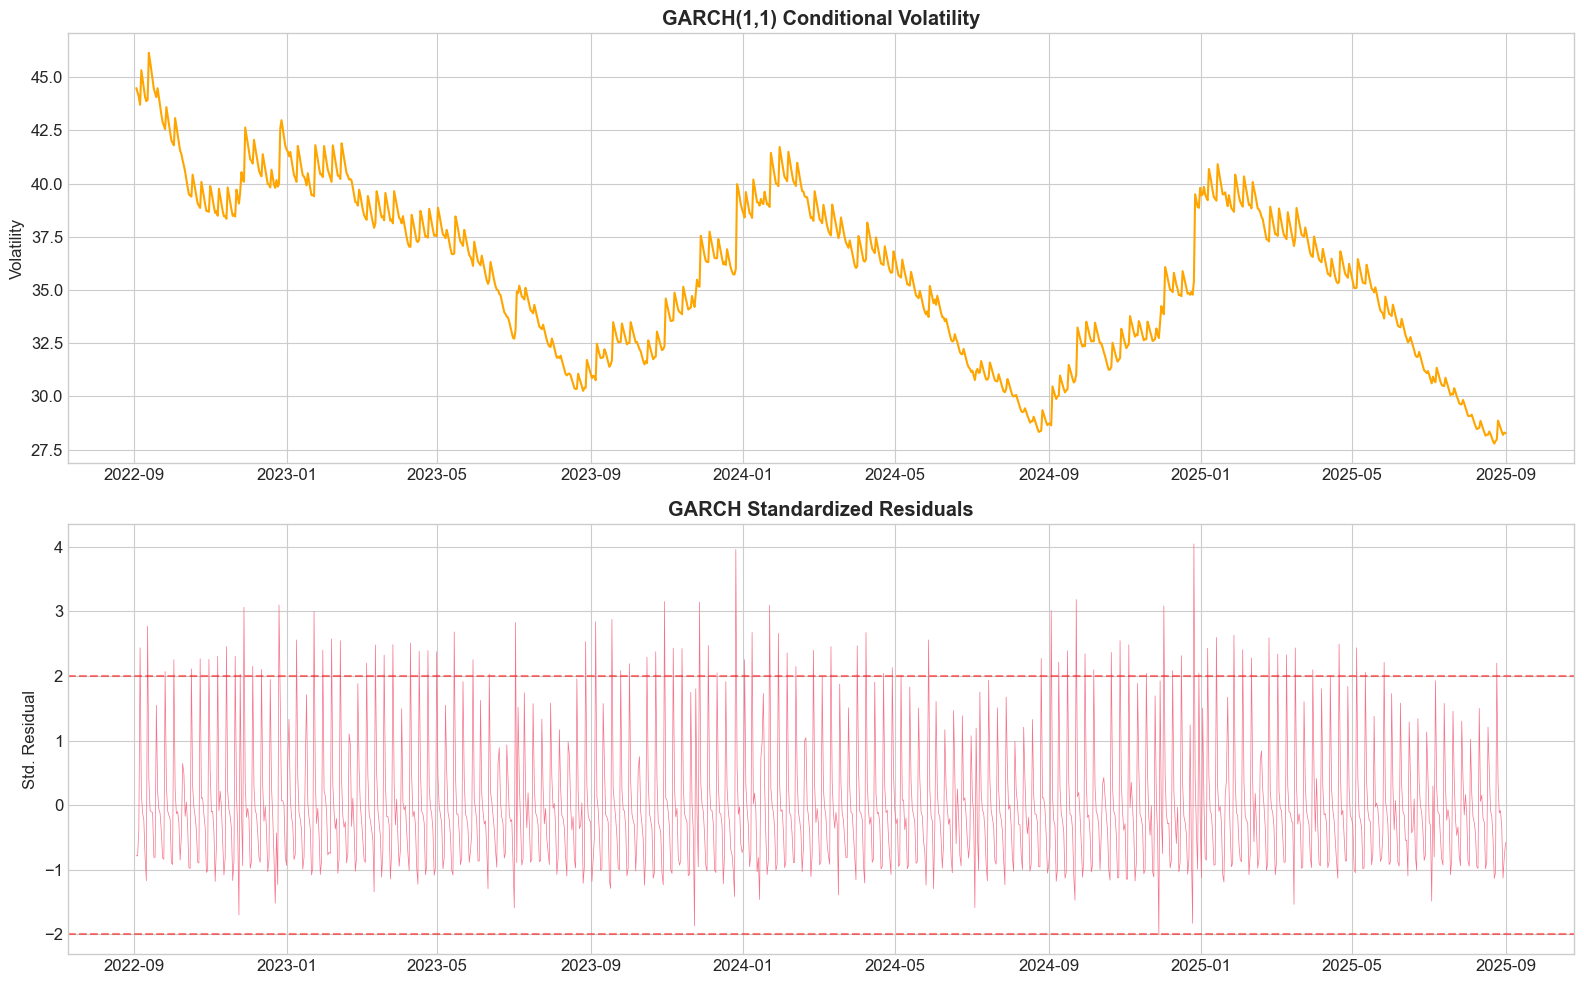


Diagnostic: ARCH test on GARCH standardized residuals
--------------------------------------------------
LM Statistic: 336.6867
p-value: 0.000000

→ Result: REMAINING ARCH EFFECTS DETECTED (p < 0.05)
  GARCH(1,1) did NOT fully capture all volatility clustering
  Recommendations:
  • Try higher-order GARCH(2,2) or GARCH(1,2)
  • Consider asymmetric models: EGARCH or GJR-GARCH
  • The model still provides useful volatility estimates


In [27]:
# GARCH forecast - conditional volatility
garch_forecast = garch_fit.forecast(horizon=len(df_test))

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Conditional volatility from training
axes[0].plot(train_returns.index, garch_fit.conditional_volatility, color='orange')
axes[0].set_title('GARCH(1,1) Conditional Volatility', fontweight='bold')
axes[0].set_ylabel('Volatility')

# Standardized residuals
std_resid = garch_fit.std_resid
axes[1].plot(train_returns.index, std_resid, linewidth=0.5)
axes[1].axhline(y=2, color='red', linestyle='--', alpha=0.5)
axes[1].axhline(y=-2, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('GARCH Standardized Residuals', fontweight='bold')
axes[1].set_ylabel('Std. Residual')

plt.tight_layout()
plt.savefig('10_garch_model.png', dpi=150, bbox_inches='tight')
plt.show()

# Test standardized residuals for remaining ARCH effects
print("\nDiagnostic: ARCH test on GARCH standardized residuals")
print("-" * 50)
arch_test_garch = het_arch(std_resid.dropna(), nlags=10)
print(f"LM Statistic: {arch_test_garch[0]:.4f}")
print(f"p-value: {arch_test_garch[1]:.6f}")

if arch_test_garch[1] < 0.05:
    print(f"\n→ Result: REMAINING ARCH EFFECTS DETECTED (p < 0.05)")
    print("  GARCH(1,1) did NOT fully capture all volatility clustering")
    print("  Recommendations:")
    print("  • Try higher-order GARCH(2,2) or GARCH(1,2)")
    print("  • Consider asymmetric models: EGARCH or GJR-GARCH")
    print("  • The model still provides useful volatility estimates")
else:
    print(f"\n→ Result: No significant remaining ARCH effects (p ≥ 0.05)")
    print("  GARCH(1,1) successfully captured volatility dynamics")

#### GARCH Results

GARCH(1,1) on ridership returns shows highly persistent volatility:

- α₁ = 0.016 (p = 0.022): Small but significant ARCH effect.
- β₁ = 0.976 (p ≈ 0): Very high persistence. α₁ + β₁ = 0.992, close to 1.0 — near-integrated (IGARCH) behavior where volatility shocks decay very slowly.
- ω = 8.84 (p = 0.14): Not significant, consistent with near-IGARCH dynamics.

The post-fit ARCH-LM test (LM = 336.69, p ≈ 0) shows GARCH(1,1) did not fully capture all volatility clustering. Higher-order GARCH(2,2) or asymmetric models (EGARCH, GJR-GARCH) may be needed. The near-IGARCH behavior suggests long memory in CTA ridership volatility.


### 7.4 Model 3: Prophet


In [28]:
# Prepare Prophet data
prophet_train = df_train[['total_rides']].reset_index()
prophet_train.columns = ['ds', 'y']

prophet_test = df_test[['total_rides']].reset_index()
prophet_test.columns = ['ds', 'y']

print("Training Prophet...")
prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
                  changepoint_prior_scale=0.05, seasonality_mode='multiplicative')
prophet.add_country_holidays(country_name='US')
prophet.fit(prophet_train)
print("Prophet trained!")

Training Prophet...


23:12:10 - cmdstanpy - INFO - Chain [1] start processing
23:12:11 - cmdstanpy - INFO - Chain [1] done processing


Prophet trained!


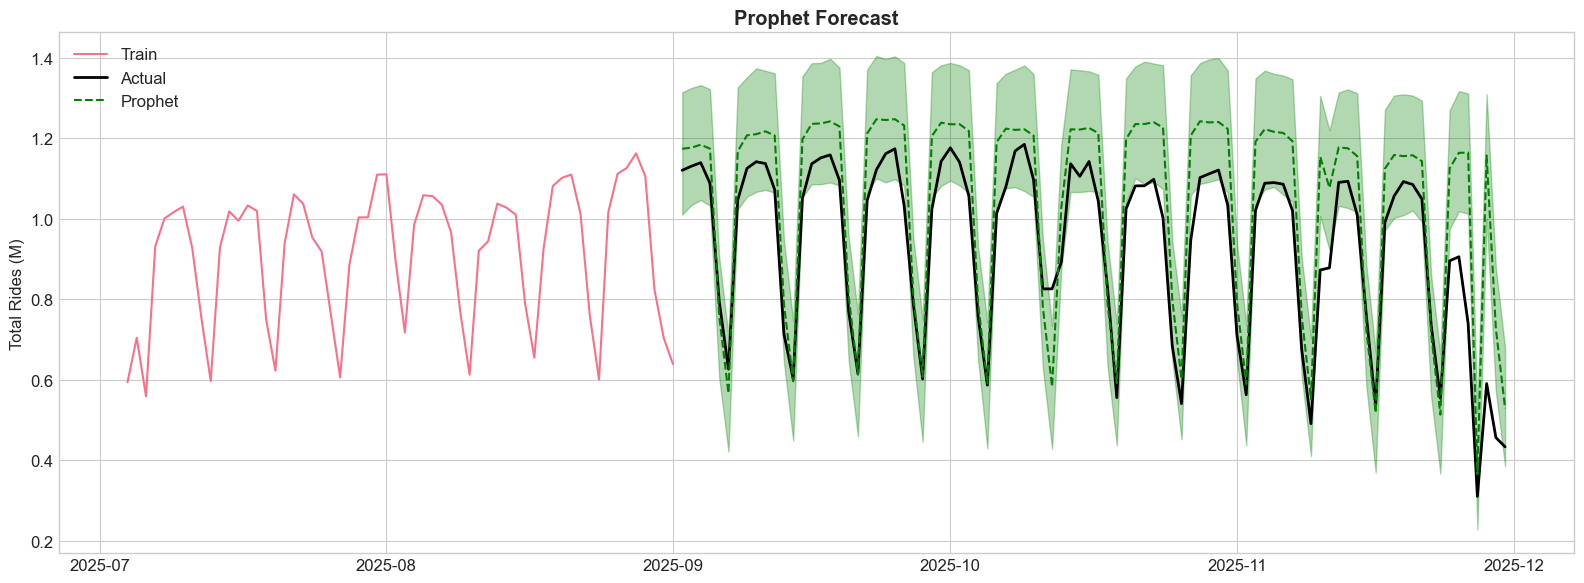

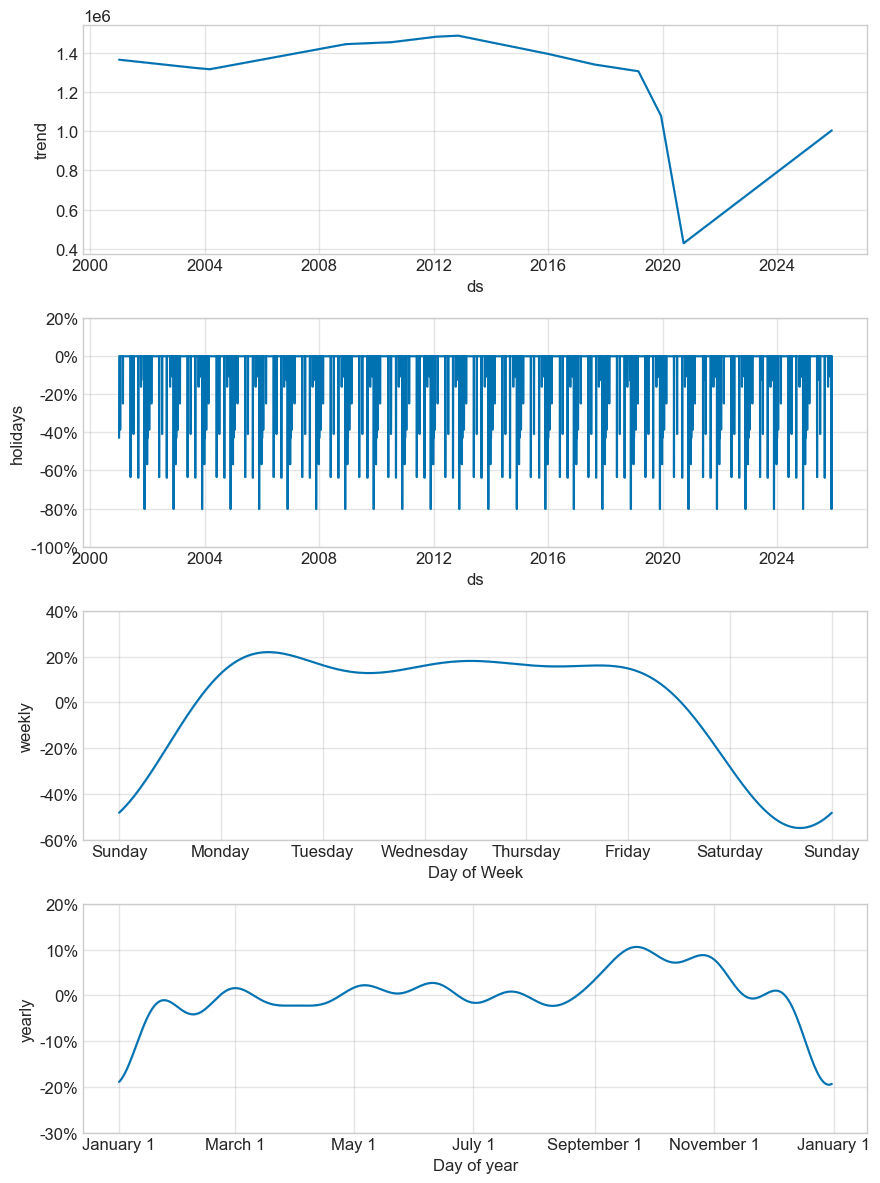

In [29]:
# Prophet Forecast
future = prophet.make_future_dataframe(periods=len(df_test))
prophet_forecast = prophet.predict(future)
prophet_pred = prophet_forecast[prophet_forecast['ds'].isin(prophet_test['ds'])]

# Plot forecast
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(prophet_train['ds'].iloc[-60:], prophet_train['y'].iloc[-60:]/1e6, label='Train')
ax.plot(prophet_test['ds'], prophet_test['y']/1e6, label='Actual', color='black', linewidth=2)
ax.plot(prophet_pred['ds'], prophet_pred['yhat']/1e6, label='Prophet', color='green', linestyle='--')
ax.fill_between(prophet_pred['ds'], prophet_pred['yhat_lower']/1e6, prophet_pred['yhat_upper']/1e6, alpha=0.3, color='green')
ax.set_ylabel('Total Rides (M)')
ax.set_title('Prophet Forecast', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('11_prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# Components
fig = prophet.plot_components(prophet_forecast)
plt.savefig('11b_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.5 Model 4: LSTM


In [ ]:
# Prepare LSTM data
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(df_train[['total_rides']])
test_scaled = scaler.transform(df_test[['total_rides']])

SEQ_LEN = 30
X_train, y_train = create_sequences(train_scaled.flatten(), SEQ_LEN)
combined = np.concatenate([train_scaled[-SEQ_LEN:], test_scaled])
X_test, y_test = create_sequences(combined.flatten(), SEQ_LEN)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (8980, 30, 1), X_test: (90, 30, 1)


In [40]:
# Build and train LSTM
print("Training LSTM...")
import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm.fit(X_train, y_train, epochs=100, batch_size=32,
                   validation_split=0.1, callbacks=[early_stop], verbose=1)
print("LSTM trained!")

Training LSTM...
Epoch 1/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0497 - mae: 0.1810 - val_loss: 0.0113 - val_mae: 0.0784
Epoch 2/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0388 - mae: 0.1638 - val_loss: 0.0101 - val_mae: 0.0792
Epoch 3/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0374 - mae: 0.1622 - val_loss: 0.0100 - val_mae: 0.0784
Epoch 4/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0344 - mae: 0.1535 - val_loss: 0.0099 - val_mae: 0.0724
Epoch 5/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0184 - mae: 0.1021 - val_loss: 0.0061 - val_mae: 0.0583
Epoch 6/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0137 - mae: 0.0835 - val_loss: 0.0060 - val_mae: 0.0567
Epoch 7/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0119 - mae: 0.0759 - val_loss: 0.0062 - val_mae: 0.0610
Epoch 8/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0108 - mae: 0.0710 - val_loss: 0.0062 - val_mae: 0.0613
Epoch 9/100
253/253 ━━━━━━━━━━

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


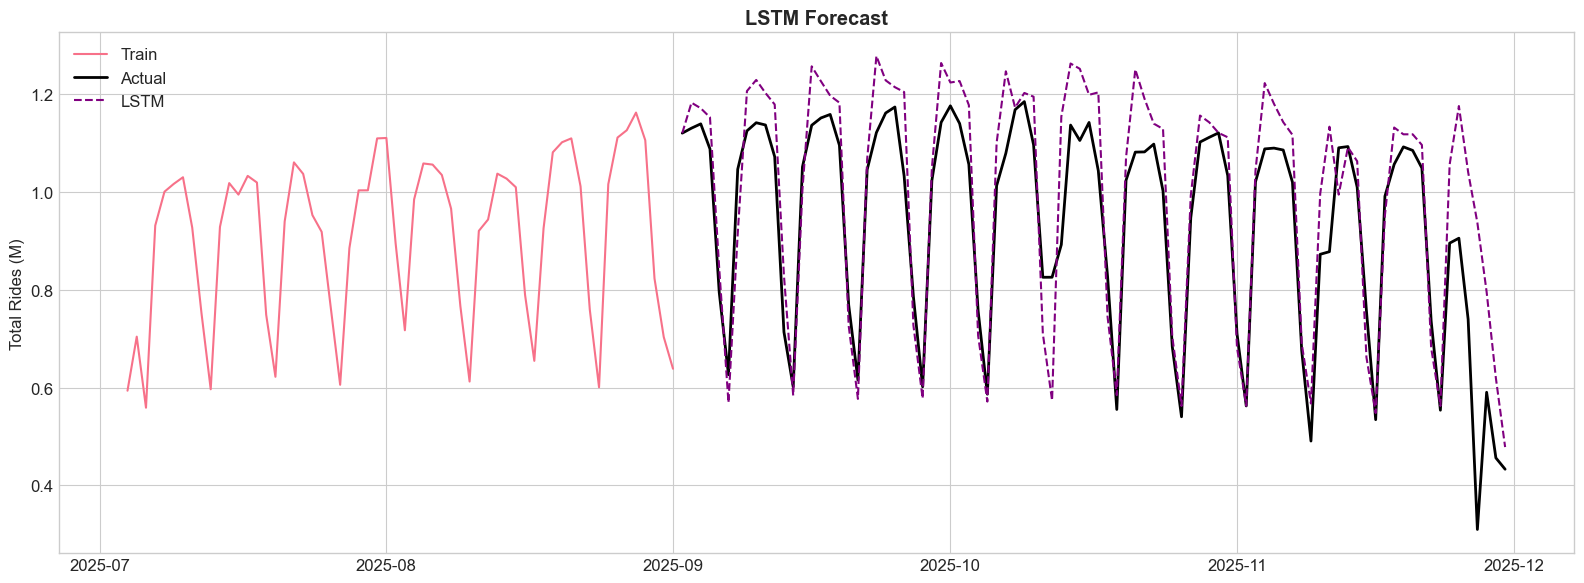

In [41]:
# LSTM Forecast
lstm_pred_scaled = lstm.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()
lstm_forecast = pd.Series(lstm_pred, index=df_test.index[:len(lstm_pred)])

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_train.index[-60:], df_train['total_rides'].iloc[-60:]/1e6, label='Train')
ax.plot(df_test.index[:len(lstm_forecast)], df_test['total_rides'].iloc[:len(lstm_forecast)]/1e6, label='Actual', color='black', linewidth=2)
ax.plot(lstm_forecast.index, lstm_forecast/1e6, label='LSTM', color='purple', linestyle='--')
ax.set_ylabel('Total Rides (M)')
ax.set_title('LSTM Forecast', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('12_lstm_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Results and Evaluation <a id='8-results'></a>

### 8.1 Metrics Calculation


In [42]:
def calc_metrics(actual, pred, name):
    n = min(len(actual), len(pred))
    actual, pred = actual[:n], pred[:n]

    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    mape = mean_absolute_percentage_error(actual, pred) * 100

    # Directional accuracy
    dir_acc = np.mean((np.diff(actual) > 0) == (np.diff(pred) > 0)) * 100

    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'Dir. Acc (%)': dir_acc}

actual = df_test['total_rides'].values

metrics = [
    calc_metrics(actual, sarima_forecast.values, 'SARIMA'),
    calc_metrics(actual, prophet_pred['yhat'].values, 'Prophet'),
    calc_metrics(actual[:len(lstm_forecast)], lstm_forecast.values, 'LSTM')
]

metrics_df = pd.DataFrame(metrics).set_index('Model')

print("="*70)
print("MODEL COMPARISON")
print("="*70)

# Format metrics for display (RMSE/MAE in millions for readability)
display_df = metrics_df.copy()
display_df['RMSE'] = display_df['RMSE'].map(lambda x: f"{x/1e6:.4f}M")
display_df['MAE'] = display_df['MAE'].map(lambda x: f"{x/1e6:.4f}M")
display_df['MAPE (%)'] = display_df['MAPE (%)'].map(lambda x: f"{x:.2f}%")
display_df['Dir. Acc (%)'] = display_df['Dir. Acc (%)'].map(lambda x: f"{x:.1f}%")
print(display_df.to_string())

# Find best model per metric
print(f"\nBest RMSE:  {metrics_df['RMSE'].idxmin()} ({metrics_df['RMSE'].min()/1e6:.4f}M)")
print(f"Best MAE:   {metrics_df['MAE'].idxmin()} ({metrics_df['MAE'].min()/1e6:.4f}M)")
print(f"Best MAPE:  {metrics_df['MAPE (%)'].idxmin()} ({metrics_df['MAPE (%)'].min():.2f}%)")
print(f"Best Dir.:  {metrics_df['Dir. Acc (%)'].idxmax()} ({metrics_df['Dir. Acc (%)'].max():.1f}%)")

MODEL COMPARISON
            RMSE      MAE MAPE (%) Dir. Acc (%)
Model                                          
SARIMA   0.2705M  0.2518M   27.72%        89.9%
Prophet  0.1447M  0.1155M   13.06%        85.4%
LSTM     0.1235M  0.0877M   11.24%        77.5%

Best RMSE:  LSTM (0.1235M)
Best MAE:   LSTM (0.0877M)
Best MAPE:  LSTM (11.24%)
Best Dir.:  SARIMA (89.9%)


#### Metrics Analysis

| Model | RMSE | MAE | MAPE | Dir. Accuracy |
|-------|------|-----|------|---------------|
| SARIMA | 0.271M | 0.252M | 27.72% | 89.9% |
| Prophet | 0.145M | 0.116M | 13.06% | 85.4% |
| LSTM | 0.1235M | 0.0877M | 11.24% | 77.5% |

LSTM achieves the best point-forecast accuracy (MAPE 11.24%, ~±105K rides/day on ~1.2M daily average). SARIMA leads in directional accuracy (89.9%), correctly predicting whether ridership goes up or down — useful for operational scheduling. Prophet offers the best interpretability-accuracy tradeoff at 13.06% MAPE with decomposable trend/weekly/yearly components.

SARIMA's high MAPE (27.72%) comes from difficulty with weekday-to-weekend magnitude swings, even though it nails their direction. The SARIMAX intervention model from Section 6 complements these by quantifying the COVID structural break — it's a causal analysis tool, not a point-forecast competitor.


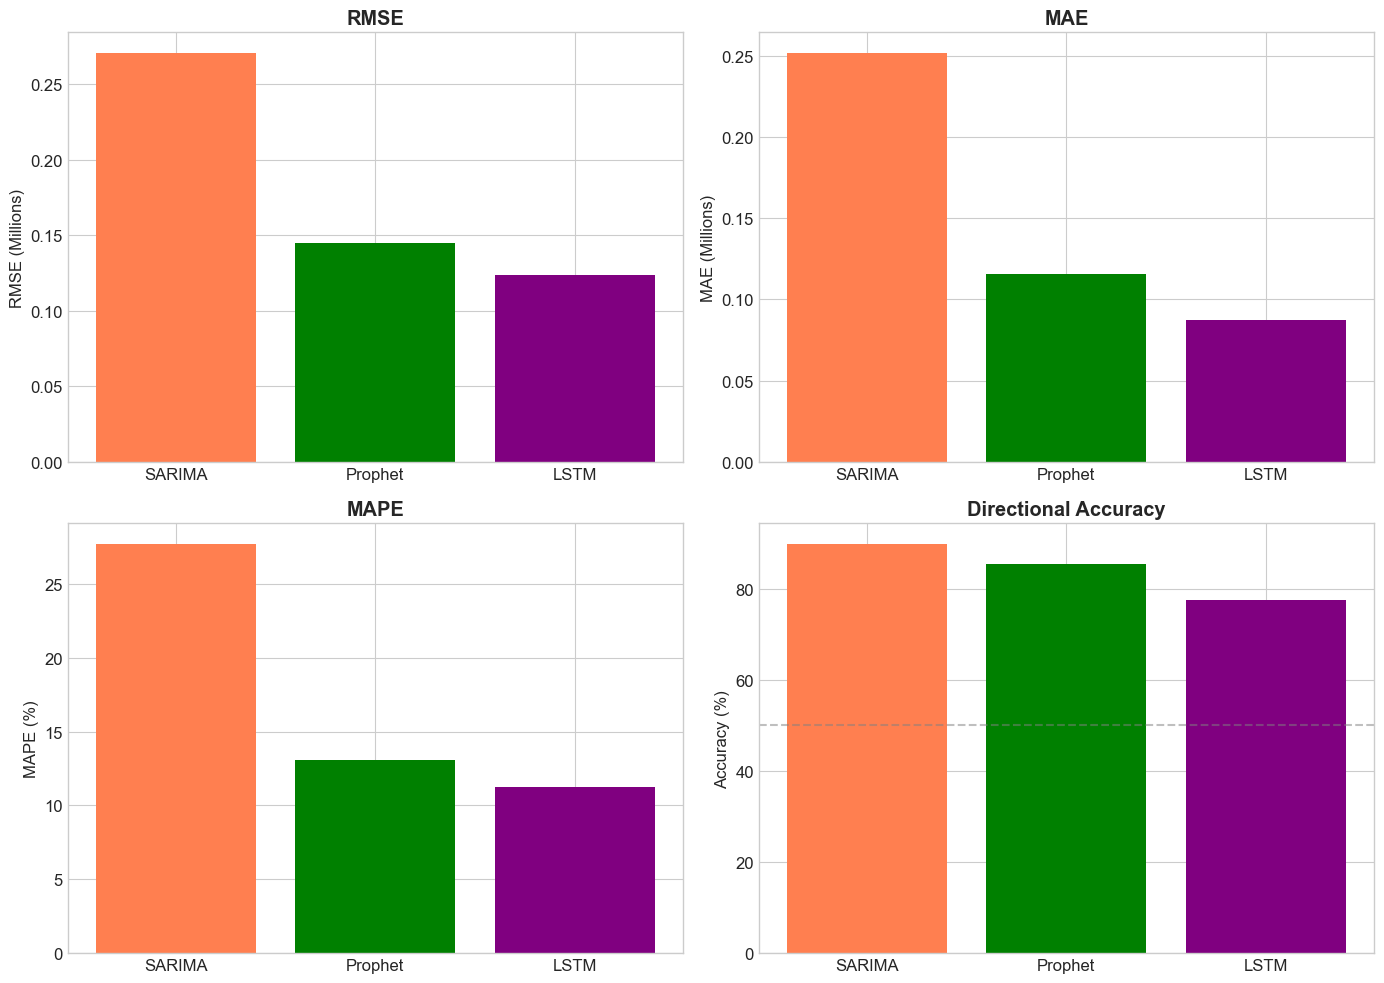

In [43]:
# Metrics visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
models = metrics_df.index.tolist()
colors = ['coral', 'green', 'purple']

axes[0, 0].bar(models, metrics_df['RMSE']/1e6, color=colors)
axes[0, 0].set_ylabel('RMSE (Millions)')
axes[0, 0].set_title('RMSE', fontweight='bold')

axes[0, 1].bar(models, metrics_df['MAE']/1e6, color=colors)
axes[0, 1].set_ylabel('MAE (Millions)')
axes[0, 1].set_title('MAE', fontweight='bold')

axes[1, 0].bar(models, metrics_df['MAPE (%)'], color=colors)
axes[1, 0].set_ylabel('MAPE (%)')
axes[1, 0].set_title('MAPE', fontweight='bold')

axes[1, 1].bar(models, metrics_df['Dir. Acc (%)'], color=colors)
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_title('Directional Accuracy', fontweight='bold')
axes[1, 1].axhline(y=50, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('13_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 All Models Comparison


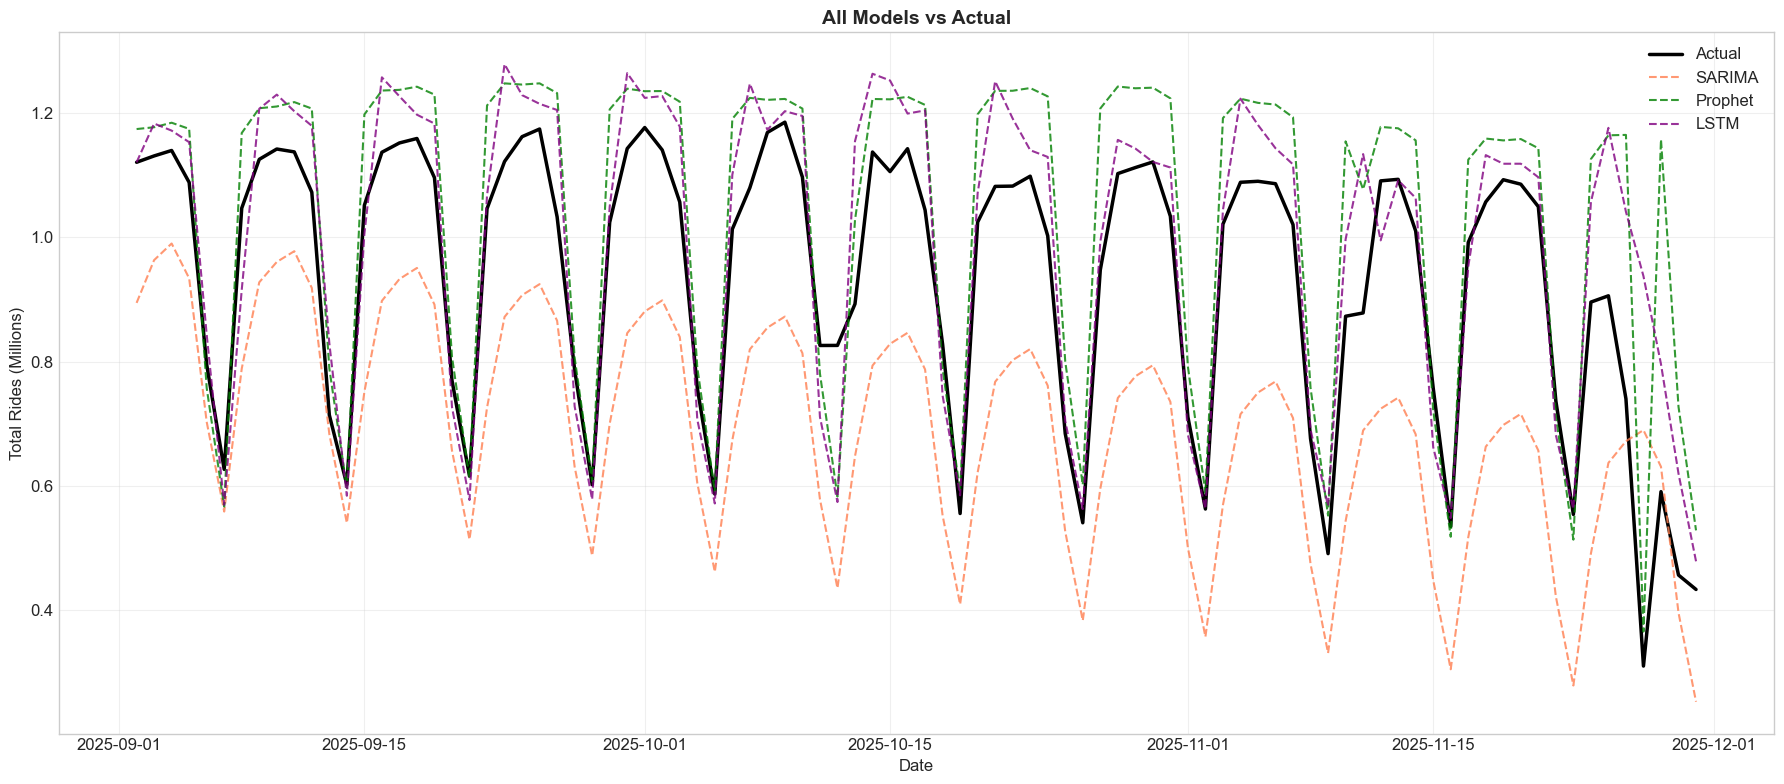

In [44]:
fig, ax = plt.subplots(figsize=(18, 8))

ax.plot(df_test.index, df_test['total_rides']/1e6, label='Actual', color='black', linewidth=2.5)
ax.plot(df_test.index, sarima_forecast/1e6, label='SARIMA', color='coral', linestyle='--', alpha=0.8)
ax.plot(prophet_pred['ds'], prophet_pred['yhat']/1e6, label='Prophet', color='green', linestyle='--', alpha=0.8)
ax.plot(lstm_forecast.index, lstm_forecast/1e6, label='LSTM', color='purple', linestyle='--', alpha=0.8)

ax.set_xlabel('Date')
ax.set_ylabel('Total Rides (Millions)')
ax.set_title('All Models vs Actual', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('14_all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Model Selection and Justification

Each model serves a different purpose in practice:

- **Point-forecast accuracy**: LSTM wins (MAPE 11.24%, RMSE 0.1235M), leveraging nonlinear patterns from its 30-day lookback window.
- **Interpretability + accuracy**: Prophet provides the best balance — decomposable components make forecasts explainable while achieving 13.06% MAPE.
- **Directional signals**: SARIMA excels at predicting ridership direction (89.9%), useful for binary scheduling decisions.
- **Volatility / risk**: GARCH captures near-integrated volatility (α+β = 0.992), though remaining ARCH effects suggest EGARCH or GJR-GARCH extensions.
- **Structural break context**: SARIMAX intervention + Causal Impact quantify the COVID regime change (−45.95%, 66.2% recovery). Essential for long-term planning.


In [8]:
comparison = pd.DataFrame({
    'Model': ['SARIMA', 'GARCH', 'Prophet', 'LSTM', 'SARIMAX (intervention)'],
    'Type': ['Statistical', 'Volatility', 'Statistical', 'Deep Learning', 'Intervention'],
    'Interpretability': ['High', 'High', 'High', 'Low', 'High'],
    'Handles Seasonality': ['Yes (single)', 'No', 'Yes (multiple)', 'Learned', 'Yes (single)'],
    'Volatility Modeling': ['No', 'Yes', 'No', 'No', 'No'],
    'Structural Break': ['No', 'No', 'No', 'No', 'Yes'],
    'Training Speed': ['Fast', 'Fast', 'Medium', 'Slow', 'Fast']
})

print("Model Comparison")
print("-" * 80)
print(comparison.to_string(index=False))

print("""
Recommendations:

  Operational forecasting -> LSTM (MAPE 11.24%), pair with Prophet for interpretability
  Interpretable forecasting -> Prophet (MAPE 13.06%, decomposable components)
  Volatility / risk -> GARCH (alpha+beta = 0.992, near-IGARCH)
  Structural break analysis -> SARIMAX + CausalImpact (-45.95%, 66.2% recovery)
  Directional baseline -> SARIMA (89.9% directional accuracy)
""")

Model Comparison
--------------------------------------------------------------------------------
                 Model          Type Interpretability Handles Seasonality Volatility Modeling Structural Break Training Speed
                SARIMA   Statistical             High        Yes (single)                  No               No           Fast
                 GARCH    Volatility             High                  No                 Yes               No           Fast
               Prophet   Statistical             High      Yes (multiple)                  No               No         Medium
                  LSTM Deep Learning              Low             Learned                  No               No           Slow
SARIMAX (intervention)  Intervention             High        Yes (single)                  No              Yes           Fast

Recommendations:

  Operational forecasting -> LSTM (MAPE 11.24%), pair with Prophet for interpretability
  Interpretable forecasting -> Prophet 

---
## 9. Future Work <a id='9-future-work'></a>


In [4]:
print("""
Future Work
-----------

Structural break extensions:
  - Markov regime-switching models (Hamilton, 1989)
  - Multiple break detection (Bai-Perron test)
  - Time-varying parameter models for recovery dynamics
  - Remote-work indices as control series in CausalImpact

Model extensions:
  - EGARCH / GJR-GARCH for remaining ARCH effects (LM=337)
  - SARIMA(1,1,1)(0,1,1,7): drop non-significant seasonal AR (p=0.211)
  - Ensemble: weighted combination of Prophet + LSTM + intervention model
  - SARIMAX with weather + holiday exogenous regressors

Additional data:
  - Weather (temperature, precipitation, wind chill)
  - Events (sports, concerts, conventions)
  - Economic indicators (gas prices, remote-work adoption)
  - CTA service alerts and planned disruptions

Deployment:
  - Automated daily forecasting pipeline
  - Real-time dashboard with confidence intervals
  - Model monitoring for concept drift
  - Regime-aware forecast selection

Methodology:
  - Expanding-window cross-validation
  - Hyperparameter tuning via Optuna
  - Station-level hierarchical forecasting
  - Transfer learning from other transit systems
""")


Future Work
-----------

Structural break extensions:
  - Markov regime-switching models (Hamilton, 1989)
  - Multiple break detection (Bai-Perron test)
  - Time-varying parameter models for recovery dynamics
  - Remote-work indices as control series in CausalImpact

Model extensions:
  - EGARCH / GJR-GARCH for remaining ARCH effects (LM=337)
  - SARIMA(1,1,1)(0,1,1,7): drop non-significant seasonal AR (p=0.211)
  - Ensemble: weighted combination of Prophet + LSTM + intervention model
  - SARIMAX with weather + holiday exogenous regressors

Additional data:
  - Weather (temperature, precipitation, wind chill)
  - Events (sports, concerts, conventions)
  - Economic indicators (gas prices, remote-work adoption)
  - CTA service alerts and planned disruptions

Deployment:
  - Automated daily forecasting pipeline
  - Real-time dashboard with confidence intervals
  - Model monitoring for concept drift
  - Regime-aware forecast selection

Methodology:
  - Expanding-window cross-validation
  

## Summary

We forecast CTA daily ridership using 9,100 observations (Jan 2001 – Nov 2025) from the Chicago Data Portal, combining classical time series methods, deep learning, and structural break analysis.

**Structural break**: The Chow test confirms a break in March 2020 (F = 1,896, p ≈ 0). The SARIMAX ramp term dominates (−3.73M/day/year), characterizing COVID's effect as a continuous divergence rather than a one-time shock. Bayesian Causal Impact estimates a 45.95% decline (posterior probability 100%), with ~175M cumulative rides lost. As of late 2025, ridership is at 66.2% of counterfactual — a permanent regime change.

**Data characteristics**: Strong weekly seasonality, trend-stationarity, confirmed ARCH effects (JB = 5,022, ARCH-LM = 3,776), near-integrated GARCH volatility (α+β = 0.992).

**90-day forecast performance**: LSTM achieved the best point accuracy (MAPE 11.24%, RMSE 0.1235M), Prophet the best interpretability-accuracy balance (MAPE 13.06%), and SARIMA the highest directional accuracy (89.9%).


In [3]:
print("""
Project Summary: CTA Ridership Forecasting
-------------------------------------------

Data: 9,100 daily observations (Jan 2001 - Nov 2025) from Chicago Data Portal

Structural Break:
  Chow test: F=1,896, p ~ 0 (pre-COVID 1.37M vs post-COVID 688K, -49.7%)
  SARIMAX: ramp dominates (-3.73M/day/year), step/pulse non-significant
  Causal Impact: -45.95% relative effect, ~175M rides lost, 100% posterior prob
  Current recovery: 66.2% of counterfactual

ARCH / Volatility:
  Jarque-Bera = 5,022, ARCH-LM = 3,776, GARCH alpha+beta = 0.992

90-day Forecast Performance:
  SARIMA:  MAPE 27.72%, Dir. Acc 89.9%
  Prophet: MAPE 13.06%, Dir. Acc 85.4%
  LSTM:    MAPE 11.24%, Dir. Acc 77.5%
""")


Project Summary: CTA Ridership Forecasting
-------------------------------------------

Data: 9,100 daily observations (Jan 2001 - Nov 2025) from Chicago Data Portal

Structural Break:
  Chow test: F=1,896, p ~ 0 (pre-COVID 1.37M vs post-COVID 688K, -49.7%)
  SARIMAX: ramp dominates (-3.73M/day/year), step/pulse non-significant
  Causal Impact: -45.95% relative effect, ~175M rides lost, 100% posterior prob
  Current recovery: 66.2% of counterfactual

ARCH / Volatility:
  Jarque-Bera = 5,022, ARCH-LM = 3,776, GARCH alpha+beta = 0.992

90-day Forecast Performance:
  SARIMA:  MAPE 27.72%, Dir. Acc 89.9%
  Prophet: MAPE 13.06%, Dir. Acc 85.4%
  LSTM:    MAPE 11.24%, Dir. Acc 77.5%

